# IMU ward-transition recognition — final reproduction notebook (JupyterLab)
*IMU 병동 전환 인식 — final 재현 노트북 (JupyterLab)*

*Sensor modality versus pretraining for recognising bed-exit–relevant postural transitions: a gyroscope-focused feasibility study on public wearable-IMU data* (MDPI *Sensors*, final)

**EN.** This notebook reproduces every figure, table and headline number of the final paper. Steps ①–⑥ run on CPU in a few minutes and produce §3.1–§3.4 with Figures 1–7 and Table 2. Steps ⑦–⑨ are the foundation-model stage and complete §3.5, Tables 1 & 3, Figure 8 and Supplementary Figure S1. Only ⑦ (embedding extraction) and ⑨ (full fine-tuning) actually need a GPU. If `results/unimts_emb_w128.npz` already exists, ⑧ runs on CPU and the frozen-probe and embedding read-outs reproduce the reported values to four decimals. The final **reproduction check** cell automatically compares the produced numbers against the values printed in the paper.

**KR.** 이 노트북은 final 논문의 모든 그림·표·수치를 재현합니다. ①–⑥은 CPU만으로 수 분 안에 돌아가며 §3.1–§3.4와 그림 1–7·표 2를 만듭니다. ⑦–⑨는 파운데이션 모델 단계로 §3.5·표 1·3·그림 8·보충 그림 S1을 완성합니다. GPU가 실제로 필요한 단계는 ⑦(임베딩 추출)과 ⑨(완전 미세조정) 둘뿐입니다. `results/unimts_emb_w128.npz`가 이미 있으면 ⑧은 CPU로 돌아가며, frozen probe와 embedding 판독이 보고 값을 네 자리까지 재현합니다. 마지막 셀의 **재현 검증**이 산출된 수치를 논문에 실린 값과 자동 대조합니다.

> **Run order / 실행 순서:** Run cell 0 (environment) and the helper cell first — every step uses the `run()` they define. To start from the middle, use **Run ▸ Run All Above Selected Cell**.
> 아래 셀 0(환경)과 헬퍼 셀을 먼저 실행하세요. 모든 단계가 거기서 정의하는 `run()`을 씁니다. 중간부터 돌리려면 메뉴 **Run ▸ Run All Above Selected Cell**.

## 0. Environment & data check
*0. 환경 설정 · 데이터 확인*

In [2]:
%automagic off   # keep run(...) from being read as IPython's %run magic / run(...)이 %run 매직으로 오해되지 않게

import os, sys, subprocess, glob, json
from pathlib import Path

REPO = Path.cwd()
assert (REPO/'src').exists(), f'src/ not found — open the notebook at the repo root / src/ 없음 — 저장소 루트에서 열세요. now: {REPO}'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
sys.path.insert(0, str(REPO/'src'))
print('repo  :', REPO)
print('python:', sys.version.split()[0])

# if data/ is missing, auto-link the sibling folder (imu_ward_har/data) as a junction
# data/ 가 없으면 옆 폴더(imu_ward_har/data)를 junction으로 자동 연결
DATA = REPO/'data'
if not DATA.exists():
    alt = REPO.parent/'imu_ward_har'/'data'
    if alt.exists():
        print('data/ missing -> trying auto-link / 자동 연결 시도:', alt)
        subprocess.run(['cmd','/c','mklink','/J',str(DATA),str(alt)], capture_output=True, text=True)
print('data  :', 'OK' if DATA.exists() else 'missing — see data setup in README / 없음 — README 참고')


Automagic is OFF, % prefix IS needed for line magics.
repo  : C:\Users\youmi\OneDrive\Desktop\Dr. P\1. Paper\SPG_MDPI-Sensors\SPG-code
python: 3.13.9
data/ missing -> trying auto-link / 자동 연결 시도: C:\Users\youmi\OneDrive\Desktop\Dr. P\1. Paper\SPG_MDPI-Sensors\imu_ward_har\data
data  : missing — see data setup in README / 없음 — README 참고


## (optional) Package install — for the foundation model (⑦–⑨)
*(선택) 패키지 설치 — 파운데이션 모델(⑦–⑨)용*

**EN.** The UniMTS source code and checkpoint are already under `external_UniMTS/` in the repo. Below are the Python packages needed to run ⑦–⑨ on a GPU; skip if you already have them. `torch.cuda.is_available()` must be `True` to use the GPU (printed at the top of ⑦–⑨).

**KR.** UniMTS 원본 코드와 체크포인트는 이미 저장소의 `external_UniMTS/`에 있습니다. 아래는 GPU에서 ⑦–⑨를 돌리는 데 필요한 파이썬 패키지입니다. 이미 있으면 건너뛰세요. `torch.cuda.is_available()`가 `True`여야 GPU를 씁니다(⑦–⑨ 첫 줄에서 출력).

In [2]:
# for the core pipeline (①–⑥) / 핵심 파이프라인(①–⑥)용:
# !pip install -r requirements.txt

# for the foundation model (⑦–⑨), CUDA 12.6 wheels / 파운데이션 모델(⑦–⑨)용, CUDA 12.6 휠:
# !pip install torch==2.13.0+cu126 torchvision --index-url https://download.pytorch.org/whl/cu126
# !pip install ftfy==6.3.1 regex git+https://github.com/openai/CLIP.git

import torch
print('torch', torch.__version__, '| CUDA available / CUDA 사용 가능:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU  :', torch.cuda.get_device_name(0))

torch 2.13.0+cu126 | CUDA 사용 가능: True
GPU  : NVIDIA GeForce RTX 4070 Laptop GPU


## Run helper
*실행 헬퍼*

**EN.** Runs each script with the current kernel's Python and streams the output. **Run this cell first.**

**KR.** 각 스크립트를 현재 커널의 파이썬으로 실행하고 출력을 스트리밍합니다. **이 셀을 반드시 먼저 실행하세요.**

In [2]:
FAILED = []   # record failed steps — the final check cell reports them / 실패 단계 기록 — 마지막 검증 셀이 보고

def run(*args):
    cmd = [sys.executable] + list(args)
    print('>>>', ' '.join(args)); sys.stdout.flush()
    r = subprocess.run(cmd, cwd=str(REPO), capture_output=True, text=True,
                       env={**os.environ, 'PYTHONIOENCODING':'utf-8'})
    if r.stdout:
        print(r.stdout[-6000:])
    if r.returncode:
        # Deliberately no exception (so later steps keep running); collect in FAILED so the
        # final check cell reports it — don't misread 'zero exceptions' as success.
        # 일부러 예외를 올리지 않음(뒤 단계 계속). FAILED에 쌓아 마지막 검증 셀이 보고 —
        # '예외 0건'을 성공으로 오독하지 않도록.
        FAILED.append((' '.join(args), r.returncode))
        print('!! exit code / 종료코드', r.returncode); print('STDERR:'); print(r.stderr[-3000:])
    return r.returncode

## Core pipeline (CPU-only reproduction — ①–⑥)
*핵심 파이프라인 (CPU만으로 재현 — ①–⑥)*

**EN.** §3.1–§3.4 and Figures 1–7 · Table 2 all come out without a GPU.

**KR.** GPU 없이 §3.1–§3.4와 그림 1–7·표 2가 모두 나옵니다.

### ① HAPT window generation (32/64/96/128 samples = 0.64–2.56 s)
*① HAPT 윈도 생성 (32/64/96/128 샘플 = 0.64–2.56 s)*

**EN.** The main analysis uses 128 (2.56 s). The window sweep (④) needs all four lengths, so we generate them in one pass.

**KR.** 주 분석은 128(2.56 s). ④ 창 스윕이 네 길이를 모두 요구하므로 한 번에 생성합니다.

In [4]:
run('src/prepare_hapt.py','--wins','32','64','96','128')

>>> src/prepare_hapt.py --wins 32 64 96 128
labelled segments 1214 | experiments 61 | subjects 30

segment duration by activity (seconds)
                    count    min  median    max
WALKING               127   2.82   19.36  28.22
WALKING_UPSTAIRS      183   4.44   12.68  17.90
WALKING_DOWNSTAIRS    186   4.32   11.77  17.60
SITTING               120  12.46   20.83  32.44
STANDING              120  15.20   22.57  40.64
LAYING                120  15.56   22.11  33.90
STAND_TO_SIT           60   1.80    3.33   6.14
SIT_TO_STAND           62   1.48    2.59   3.66
SIT_TO_LIE             60   2.72    4.04   6.52
LIE_TO_SIT             60   2.28    3.58   5.60
STAND_TO_LIE           58   2.78    4.73   9.88
LIE_TO_STAND           58   2.36    3.62   6.46

window 32 samples (0.64s), stride 16
  segments dropped (shorter than window): 0
  windows: (49190, 32, 6)

  window count by ward-10 class
    LYING              8374
    SITTING            7741
    STANDING           8456
    WALKING  

0

### ①-b 12-class HAPT baseline — §3.1 / Figure 2
*①-b 12-class HAPT 베이스라인 — §3.1 / 그림 2*

**EN.** Decomposes the standard 12-class headline (accuracy 0.937, fold macro-F1 0.854) by class. Deterministic with the CPU histogram builder; `--device cuda` is faster but shifts values slightly.

**KR.** 표준 12-class 헤드라인(정확도 0.937, fold macro-F1 0.854)을 클래스별로 분해합니다. CPU 히스토그램 빌더로 결정적. `--device cuda`는 빠르지만 값이 미세하게 달라집니다.

In [5]:
run('src/run_e1.py')   # CPU is fine; add --device cuda for GPU speed / CPU 그대로 가능, 속도 필요시 --device cuda

>>> src/run_e1.py
extracting features ...
feature matrix: (10929, 150)

Task A - standard 12-class HAPT
  [12-class] fold 1/5  macro-F1 0.883  (test subjects: 6)
  [12-class] fold 2/5  macro-F1 0.821  (test subjects: 6)
  [12-class] fold 3/5  macro-F1 0.879  (test subjects: 6)
  [12-class] fold 4/5  macro-F1 0.869  (test subjects: 6)
  [12-class] fold 5/5  macro-F1 0.820  (test subjects: 6)

  headline accuracy : 0.9373
  macro-F1          : 0.8545 +/- 0.0280

  per-class F1 (same model, no class-count confound):
             class    n     f1                   group
            LAYING 1958 0.9985                   LYING
  WALKING_UPSTAIRS 1544 0.9578 STAIRS (absent in ward)
WALKING_DOWNSTAIRS 1407 0.9535 STAIRS (absent in ward)
           WALKING 1722 0.9524                 WALKING
          STANDING 1979 0.9150                STANDING
           SITTING 1801 0.9067                 SITTING
      SIT_TO_STAND   33 0.8923              TRANSITION
      STAND_TO_SIT   70 0.8194           

0

### ② Gyroscope ablation — §3.2 / Figure 4 (headline finding)
*② 자이로 절제 — §3.2 / 그림 4 (대표 발견)*

**EN.** 6-axis vs 3-axis: macro-F1 0.822→0.647, bed-exit 0.657→0.351.

**KR.** 6축 vs 3축: macro-F1 0.822→0.647, 침대 이탈 0.657→0.351.

In [6]:
run('src/run_ablation.py','--wins','128')

>>> src/run_ablation.py --wins 128

window 128 samples (2.56s) | 7978 windows | 30 subjects
  acc+gyro   n_features=150  subject-mean macro-F1 0.8225 +/- 0.1016
  acc_only   n_features= 75  subject-mean macro-F1 0.6467 +/- 0.1010

  paired over subjects - macro-F1:
    acc+gyro             0.8225 +/- 0.1016
    acc_only             0.6467 +/- 0.1010
    diff +0.1758  95% CI [+0.1442, +0.2085]  p=5.59e-09  rank-biserial=+0.991  (29/30 subjects favour acc+gyro)

  paired over subjects - bed-exit F1 (LIE_TO_SIT, LIE_TO_STAND):
    acc+gyro             0.6575 +/- 0.2547
    acc_only             0.3512 +/- 0.2138
    diff +0.3063  95% CI [+0.2025, +0.4164]  p=3.41e-05  rank-biserial=+0.897  (26/30 subjects favour acc+gyro)

  pooled per-class F1:
              acc+gyro  acc_only   delta
LYING           0.9982    0.9959  0.0023
SITTING         0.9120    0.8239  0.0881
STANDING        0.9237    0.8410  0.0827
WALKING         0.9991    0.9983  0.0008
STAND_TO_SIT    0.8429    0.6174  0.2255
SI

0

### ③ 10-class task + confusion matrix — §3.1 / Figure 3
*③ 10-class 과제 + 혼동행렬 — §3.1 / 그림 3*

**EN.** Per-subject macro-F1 0.822, bed-exit 0.657; confusion matrix (Figure 3).

**KR.** 피험자별 macro-F1 0.822, 침대 이탈 0.657; 혼동행렬(그림 3).

In [7]:
run('src/run_transitions.py','--wins','128')

>>> src/run_transitions.py --wins 128

=== window 128 samples (2.56s) | 7978 windows ===
    fold 1/5  macro-F1 0.847
    fold 2/5  macro-F1 0.879
    fold 3/5  macro-F1 0.883
    fold 4/5  macro-F1 0.817
    fold 5/5  macro-F1 0.740

  accuracy 0.9436 | macro-F1 0.8330 +/- 0.0525

  per-class F1:
       class    n     f1
       LYING 1958 0.9982
     SITTING 1801 0.9120
    STANDING 1979 0.9237
     WALKING 1722 0.9991
STAND_TO_SIT   70 0.8429
SIT_TO_STAND   33 0.9231
  SIT_TO_LIE  107 0.7009
  LIE_TO_SIT   85 0.7101
STAND_TO_LIE  139 0.7279
LIE_TO_STAND   84 0.6625

  confusion matrix (rows = true, cols = predicted):
              LYING  SITTING  STANDING  WALKING  STAND_TO_SIT  SIT_TO_STAND  SIT_TO_LIE  LIE_TO_SIT  STAND_TO_LIE  LIE_TO_STAND
LYING          1957        0         0        0             0             0           1           0             0             0
SITTING           1     1638       156        0             4             0           0           0             2    

0

### ④ Window-length sweep — §3.3 / Figure 6 · Table 2
*④ 창 길이 스윕 — §3.3 / 그림 6 · 표 2*

**EN.** 0.64→2.56 s: macro-F1 0.720→0.833 (survivorship bias removed).

**KR.** 0.64→2.56 s: macro-F1 0.720→0.833 (생존편향 제거).

In [8]:
run('src/run_window_fair.py')

>>> src/run_window_fair.py
segments total          : 1214
segments in common set  : 1174
segments excluded       : 40
  win 0.64s  n= 35473  macro-F1 0.7198  trans 0.5889  bed-exit 0.5567
  win 1.28s  n= 17146  macro-F1 0.7636  trans 0.6431  bed-exit 0.6095
  win 1.92s  n= 11024  macro-F1 0.8062  trans 0.7150  bed-exit 0.6798
  win 2.56s  n=  7978  macro-F1 0.8330  trans 0.7612  bed-exit 0.6863

=== fair sweep: identical segments at every window length ===
 win_sec  n_windows  macro_f1  macro_f1_sd  f1_transitions  f1_bed_exit
    0.64      35473    0.7198       0.0284          0.5889       0.5567
    1.28      17146    0.7636       0.0082          0.6431       0.6095
    1.92      11024    0.8062       0.0180          0.7150       0.6798
    2.56       7978    0.8330       0.0525          0.7612       0.6863

saved -> C:\Users\youmi\OneDrive\Desktop\Dr. P\1. Paper\IMU-Ward-Transition_MDPI-Sensors\imu-ward-transition-code\results\window_fair.csv



0

### ⑤ Label efficiency — §3.4 / Figure 7
*⑤ 라벨 효율 — §3.4 / 그림 7*

**EN.** `run_fm_compare.py` runs only the hand-crafted 6-axis/3-axis arms (no embeddings), producing **§3.4 and Figure 7 without a GPU** (3-seed mean). 5 min→full: macro-F1 0.435→0.815, bed-exit 0.180→0.640, bouts 2.7→25.1→91.2. Without embeddings the full-label result is saved to `fm_compare_handonly_w128.json`, so it does not overwrite the 4-arm output used in §3.5.

**KR.** `run_fm_compare.py`가 임베딩 없이 수작업 6축·3축 arm만 돌아 **GPU 없이 §3.4와 그림 7**을 냅니다(3-시드 평균). 5분→전체: macro-F1 0.435→0.815, 침대 이탈 0.180→0.640, bout 2.7→25.1→91.2. 임베딩이 없으면 전체 라벨 결과는 `fm_compare_handonly_w128.json`으로 저장되어 §3.5용 4-arm 산출물을 덮어쓰지 않습니다.

In [9]:
run('src/run_fm_compare.py','--win','128')

>>> src/run_fm_compare.py --win 128
957
    hand3+xgb            0.6467 +/- 0.1010
    diff +0.0843  95% CI [+0.0478, +0.1218]  p=1.89e-04  rank-biserial=+0.738  (24/30 subjects favour unimts3+logreg)
  -- hand6+xgb
    hand6+xgb            0.8225 +/- 0.1016
    hand3+xgb            0.6467 +/- 0.1010
    diff +0.1758  95% CI [+0.1442, +0.2085]  p=5.59e-09  rank-biserial=+0.991  (29/30 subjects favour hand6+xgb)

  paired over subjects vs hand3+xgb, bed-exit F1:
  -- unimts3+xgb
    unimts3+xgb          0.4432 +/- 0.2351
    hand3+xgb            0.3512 +/- 0.2138
    diff +0.0920  95% CI [-0.0001, +0.1849]  p=6.43e-02  rank-biserial=+0.407  (17/30 subjects favour unimts3+xgb)
  -- unimts3+logreg
    unimts3+logreg       0.5345 +/- 0.2395
    hand3+xgb            0.3512 +/- 0.2138
    diff +0.1833  95% CI [+0.0944, +0.2726]  p=9.15e-04  rank-biserial=+0.730  (21/30 subjects favour unimts3+logreg)
  -- hand6+xgb
    hand6+xgb            0.6575 +/- 0.2547
    hand3+xgb            0.3512 +/

0

### ⑥ Figure & table generation — Figures 1–8 · S1, Tables 1–3
*⑥ 그림·표 생성 — 그림 1–8 · S1, 표 1–3*

**EN.** `make_figures`/`make_extra_figures` build Figures 1–4·7–8, Supplementary Figure S1, and Tables 1·3; `make_results_extras` builds **Figure 5 (per-subject paired) · Figure 6 · Table 2 (window length)**. Figure 5 recomputes per-subject 6-axis/3-axis scores, so it takes 2–3 min. Table 1 needs the foundation-model output (⑦–⑧). If that output is absent, Figures 8·S1 are redrawn from the archived `table2_headline.csv` and the cell says so on screen. The last line syncs the repo `figures/`·`results/` output to the manuscript asset folders. A `manuscript-only` count of 0 means every figure/table in the paper was produced by this repo.

**KR.** `make_figures`·`make_extra_figures`가 그림 1–4·7–8과 보충 그림 S1, 표 1·3을, `make_results_extras`가 **그림 5(피험자별 대응)·그림 6·표 2(창 길이)**를 만듭니다. 그림 5는 피험자별 6축/3축 점수를 재계산하므로 2–3분 걸립니다. 표 1은 파운데이션 모델 산출물(⑦–⑧)이 있어야 나옵니다. 그림 8·S1은 그 산출물이 없으면 보관된 `table2_headline.csv`에서 되그리며, 그때는 그렇게 했다고 화면에 알립니다. 마지막 줄이 저장소 `figures/`·`results/` 산출물을 원고 자산 폴더로 동기화합니다. `manuscript-only`가 0이면 원고의 모든 그림·표를 이 저장소가 만들었다는 뜻입니다.

In [10]:
run('src/make_figures.py')
run('src/make_extra_figures.py')
run('src/make_results_extras.py')

# sync repo output -> manuscript asset folders (manuscript/analysis/figures, analysis/tables)
# 저장소 산출물 → 원고 자산 폴더 동기화
print(subprocess.run([sys.executable, str(REPO.parent/'sync_manuscript_assets.py')],
                    capture_output=True, text=True).stdout)

>>> src/make_figures.py
fig1 done
fig2 done
fig3 done
fig4 done
figS1 done

=== Table 1: per-class F1 (full labels) ===
              Hand-crafted 6-axis + XGBoost  Hand-crafted 3-axis + XGBoost  UniMTS embedding + XGBoost  UniMTS frozen linear probe  UniMTS full fine-tune
Class                                                                                                                                                    
Lying                                 0.998                          0.996                       0.967                       0.979                  0.986
Sitting                               0.912                          0.824                       0.814                       0.822                  0.837
Standing                              0.924                          0.841                       0.841                       0.847                  0.842
Walking                               0.999                          0.998                       0.999        

## Foundation model (⑦–⑨) — GPU
*파운데이션 모델 (⑦–⑨) — GPU*

**EN.** Completes §3.5 · Tables 1·3 · Figure 8 · Supplementary Figure S1. Needs the source code and checkpoint (UniMTS.pth) under `external_UniMTS/` and the torch/CLIP from the cell above. **Only ⑦ (embeddings) and ⑨ (full fine-tuning) need a GPU;** ⑧ runs on CPU. Before running, each cell snapshots the archived output (embeddings, reported-value JSON) so a re-run does not erase the reported values.

**KR.** §3.5·표 1·3·그림 8·보충 그림 S1을 완성합니다. `external_UniMTS/`의 원본 코드·체크포인트(UniMTS.pth)와 위 셀의 torch/CLIP이 있어야 합니다. **⑦(임베딩)과 ⑨(완전 미세조정)만 GPU가 필요합니다.** ⑧은 CPU로 돕니다. 각 셀은 실행 전에 보관된 산출물(임베딩·보고 값 JSON)을 스냅샷으로 남겨, 재실행이 보고 값을 지우지 않게 합니다.

### Check: the public UniMTS checkpoint is 3-channel (accelerometer-only)
*검증: 공개 UniMTS 체크포인트는 3채널(가속도 전용)*

**EN.** First-layer batch-norm width 66 = 22 joints × 3 → there is structurally no slot for a gyroscope channel.

**KR.** 첫 층 배치 정규화 폭 66 = 22관절 × 3 → 자이로 채널이 들어갈 자리가 구조적으로 없음.

In [11]:
run('src/check_unimts_ckpt.py')

>>> src/check_unimts_ckpt.py
checkpoint: UniMTS.pth  (327 keys)

acc.st_gcn_networks.0.gcn.conv.weight : (192, 3, 1, 1)
acc.data_bn.weight                    : (66,)

inferred in_channels        = 3
inferred joints x channels  = 66 = 22 x 3

configuration table (contrastive.py):
  gyro=0 stft=0 -> in_channels= 3, data_bn= 66  <== MATCHES RELEASED CHECKPOINT
  gyro=0 stft=1 -> in_channels= 6, data_bn=132
  gyro=1 stft=0 -> in_channels= 6, data_bn=132
  gyro=1 stft=1 -> in_channels=12, data_bn=264

acc-encoder keys carrying an input-channel dimension:
  acc.data_bn.weight                                   (66,)
  acc.data_bn.bias                                     (66,)
  acc.data_bn.running_mean                             (66,)
  acc.data_bn.running_var                              (66,)
  acc.data_bn.num_batches_tracked                      ()
  acc.st_gcn_networks.0.gcn.conv.weight                (192, 3, 1, 1)
  acc.st_gcn_networks.0.gcn.conv.bias                  (192,)



0

### ⑦ UniMTS embedding extraction — GPU
*⑦ UniMTS 임베딩 추출 — GPU*

**EN.** Regenerates embeddings from `external_UniMTS/checkpoint/UniMTS.pth`. Before running it snapshots the archived copy to `unimts_emb_w128.archived.npz`, and after running checks the new embeddings match the archive. If they match (the expected case), ⑧ skips recomputation.

**KR.** `external_UniMTS/checkpoint/UniMTS.pth`로 임베딩을 새로 만듭니다. 실행 전에 보관본을 `unimts_emb_w128.archived.npz`로 스냅샷하고, 실행 후 새 임베딩이 보관본과 같은지 확인합니다. 같으면(예상되는 경우) ⑧이 재계산 없이 넘어갑니다.

In [12]:
import shutil, numpy as np
_emb = REPO/'results'/'unimts_emb_w128.npz'
_arch = REPO/'results'/'unimts_emb_w128.archived.npz'
if _emb.exists() and not _arch.exists():
    shutil.copy2(_emb, _arch)
    print('archived embedding snapshot / 보관 임베딩 스냅샷 ->', _arch.name)

rc = run('src/unimts_embed.py','--win','128','--gyro','0','--padding','64')

EMB_CHANGED = True
if rc == 0 and _arch.exists() and _emb.exists():
    a = np.load(_arch); b = np.load(_emb)
    key = 'emb' if 'emb' in a.files else a.files[0]
    d = float(np.abs(a[key].astype('float64') - b[key].astype('float64')).max())
    EMB_CHANGED = d > 1e-5
    print(f'new vs archived embedding max abs diff / 새 임베딩 vs 보관본 최대 절대차 {d:.2e}  ->',
          'identical (⑧ recompute not needed) / 동일 (⑧ 재계산 불필요)' if not EMB_CHANGED
          else 'differs (⑧ recompute needed) / 차이 있음 (⑧ 재계산 필요)')
elif rc != 0:
    print('⑦ failed — using the archived embeddings as-is / ⑦ 실패 — 보관 임베딩 그대로 사용.')
    EMB_CHANGED = False

>>> src/unimts_embed.py --win 128 --gyro 0 --padding 64
windows (7978, 128, 6) | acc range (g) [-1.63, 1.98] | gyro range [-6.32, 5.96]
model input (7978, 3, 64, 22, 1)  (N, C, T, V, M) | gyro=0 | padding=64
device: cuda
checkpoint loaded | missing=0 unexpected=0
  0/7978
  2560/7978
  5120/7978
  7680/7978
embeddings (7978, 512)
saved -> C:\Users\youmi\OneDrive\Desktop\Dr. P\1. Paper\IMU-Ward-Transition_MDPI-Sensors\imu-ward-transition-code\results\unimts_emb_w128.npz

새 임베딩 vs 보관본 최대 절대차 0.00e+00  -> 동일 (⑧ 재계산 불필요)


### ⑧ Representation comparison (all 4 arms) — §3.5 / Tables 1·3 / Figures 8 · S1
*⑧ 표현 비교 (전체 4-arm) — §3.5 / 표 1·3 / 그림 8 · S1*

**EN.** ⑤ already computes the 4 arms. This recomputes **only if ⑦ actually changed the embeddings**, otherwise it skips (avoiding a 50-min duplicate that also recomputes label efficiency). Set `FORCE = True` to always recompute. This step runs without a GPU.

**KR.** ⑤에서 이미 4-arm이 계산됩니다. **⑦로 임베딩이 실제로 바뀐 경우에만** 다시 계산하고, 아니면 건너뜁니다(라벨 효율까지 재계산하는 50분짜리 중복을 피함). `FORCE = True`로 무조건 재계산할 수 있습니다. 이 단계는 GPU 없이 돕니다.

In [13]:
FORCE = False   # set True to always recompute / 무조건 재계산하려면 True

_fm = REPO/'results'/'fm_compare_w128.json'
_have4 = False
if _fm.exists():
    _j = json.loads(_fm.read_text())
    _have4 = all(k in _j for k in ('unimts3+logreg', 'unimts3+xgb'))
_emb_changed = globals().get('EMB_CHANGED', False)

if _have4 and not _emb_changed and not FORCE:
    print('skip — 4-arm result already present and embeddings unchanged / 건너뜀 — 4-arm 결과 있고 임베딩 그대로.')
    for k in ('hand6+xgb', 'hand3+xgb', 'unimts3+xgb', 'unimts3+logreg'):
        v = _j[k]
        print(f"    {k:16} macro-F1 {v['macro_f1_subject_mean']:.4f}"
              f"   bed-exit {v['bed_exit_f1_subject_mean']:.4f}")
else:
    why = 'FORCE' if FORCE else ('embeddings changed / 임베딩 변경' if _emb_changed else 'no 4-arm / 4-arm 없음')
    print(f're-run run_fm_compare ({why}) — also recomputes label efficiency, tens of minutes / 라벨 효율까지 재계산, 수십 분.')
    run('src/run_fm_compare.py','--win','128')

건너뜀 — 4팔 결과가 이미 있고 임베딩도 그대로입니다.
    hand6+xgb        macro-F1 0.8225   bed-exit 0.6575
    hand3+xgb        macro-F1 0.6467   bed-exit 0.3512
    unimts3+xgb      macro-F1 0.7010   bed-exit 0.4432
    unimts3+logreg   macro-F1 0.7310   bed-exit 0.5345


### ⑨ Full fine-tuning — §3.5 (GPU)
*⑨ 완전 미세조정 — §3.5 (GPU)*

**EN.** About 8 min per fold, 5 folds. **CUDA fine-tuning is not bit-reproducible** (see README): the paper reports the **3-seed mean, macro 0.774 ± 0.019 / bed-exit 0.610 ± 0.021**, and individual runs vary within that spread — this is not an error. Each seed is written to its own file; the canonical `finetune_full_w128.json` (the seed-0 reference run, 0.7726 / 0.5550) is snapshotted to `finetune_full_w128.reported.json` and left untouched (the loop uses `--tag`), so it is always recoverable and ⑥ keeps redrawing the figures identically. After the seed loop the cell runs `aggregate_finetune_seeds.py` to produce the 3-seed `finetune_full_w128_multiseed.json` that the manuscript and the final check read.

Set `SMOKE = False` for the full three-seed run; `SMOKE = True` runs fold 1 only per seed and writes no file.

**KR.** 폴드당 약 8분, 5-fold. **CUDA 미세조정은 bit-재현이 되지 않습니다**(README 참고): 논문은 **3-시드 평균 macro 0.774 ± 0.019 / 침대이탈 0.610 ± 0.021**을 보고하며, 개별 실행은 그 범위 안에서 달라집니다 — 오류가 아닙니다. 각 시드는 별도 파일로 저장되고, 기준 파일 `finetune_full_w128.json`(seed-0 기준 실행, 0.7726 / 0.5550)은 `finetune_full_w128.reported.json`으로 스냅샷 후 보존됩니다(루프가 `--tag` 사용). 따라서 항상 복구 가능하고 ⑥이 그림을 동일하게 다시 그립니다. 시드 루프 뒤 `aggregate_finetune_seeds.py`가 원고와 최종 검증이 읽는 3-시드 `finetune_full_w128_multiseed.json`을 만듭니다.

`SMOKE = False`면 전체 3-시드 실행, `True`면 시드별 폴드 1만 돌고 파일을 쓰지 않습니다.

In [4]:
# ⑨ Full fine-tuning — multi-seed (M2). Each seed varies the fold split, weight init and
# training, quantifying between-seed variance. Each seed is saved to its own file (--tag);
# the canonical finetune_full_w128.json (seed-0 reference) is left untouched. After the loop
# we aggregate the seeds into the 3-seed mean±SD the paper reports (0.774±0.019 / 0.610±0.021).
# ⑨ 완전 미세조정 — 다중 시드(M2). 각 시드가 폴드 분할·가중치 초기화·학습을 바꿔 시드 간
# 분산을 정량화합니다. 각 시드는 별도 파일(--tag)로 저장되고 기준 파일 finetune_full_w128.json
# (seed-0)은 보존됩니다. 루프 뒤 시드들을 논문 보고용 3-시드 평균±표준편차로 집계합니다.
SEEDS = [0, 1, 2]      # seeds to run; [0] for one / 시드 목록, [0]이면 하나
SMOKE = False          # True -> each seed runs fold 1 only, writes no file / 폴드1만, 파일 미기록

import shutil
_ft = REPO/'results'/'finetune_full_w128.json'
_ftrep = REPO/'results'/'finetune_full_w128.reported.json'
if _ft.exists() and not _ftrep.exists():
    shutil.copy2(_ft, _ftrep)
    print('reported-value snapshot / 보고 값 스냅샷 ->', _ftrep.name)

for s in SEEDS:
    print('===== seed', s, '=====')
    args = ['src/run_finetune.py', '--mode', 'full', '--epochs', '20',
            '--padding', '64', '--seed', str(s), '--tag', '_seed' + str(s)]
    if SMOKE:
        args.append('--smoke')
    run(*args)

print('seed files produced / 생성된 시드 파일:')
for s in SEEDS:
    f = REPO/'results'/('finetune_full_w128_seed' + str(s) + '.json')
    print('  ', f.name, 'OK' if f.exists() else '(missing - SMOKE or failed)')

# aggregate the seed files into the 3-seed mean±SD reported in the paper (writes multiseed json)
# 시드 파일들을 논문 보고용 3-시드 평균±표준편차로 집계 (multiseed json 생성)
if not SMOKE:
    run('src/aggregate_finetune_seeds.py')

===== seed 0 =====
>>> src/run_finetune.py --mode full --epochs 20 --padding 64 --seed 0 --tag _seed0
device: cuda | mode: full | epochs 20 | seed 0
preprocessing to UniMTS input (3-channel, padding=64) ...
  fold 1/5  macro-F1 0.7847  (379s elapsed)
  fold 2/5  macro-F1 0.8328  (747s elapsed)
  fold 3/5  macro-F1 0.8493  (1124s elapsed)
  fold 4/5  macro-F1 0.7937  (1495s elapsed)
  fold 5/5  macro-F1 0.7387  (1870s elapsed)

=== UniMTS fine-tune (full) ===
subject-mean macro-F1 : 0.7841 +/- 0.0836
subject-mean bed-exit : 0.6355

per-class F1:
  LYING          0.9850
  SITTING        0.7924
  STANDING       0.8162
  WALKING        0.9988
  STAND_TO_SIT   0.8429
  SIT_TO_STAND   0.9275
  SIT_TO_LIE     0.6891
  LIE_TO_SIT     0.6966
  STAND_TO_LIE   0.6593
  LIE_TO_STAND   0.6335

  fine-tuned UniMTS vs 6-axis hand-crafted (paired, macro-F1):
    unimts-ft-full       0.7841 +/- 0.0836
    hand6+xgb            0.8225 +/- 0.1016
    diff -0.0384  95% CI [-0.0647, -0.0108]  p=6.19e-03  ra

## Result figure preview (final — 8 main + Supplementary S1)
*결과 그림 미리보기 (final — 본문 8개 + 보충 S1)*

Figure / 그림 1: fig_pipeline.png 


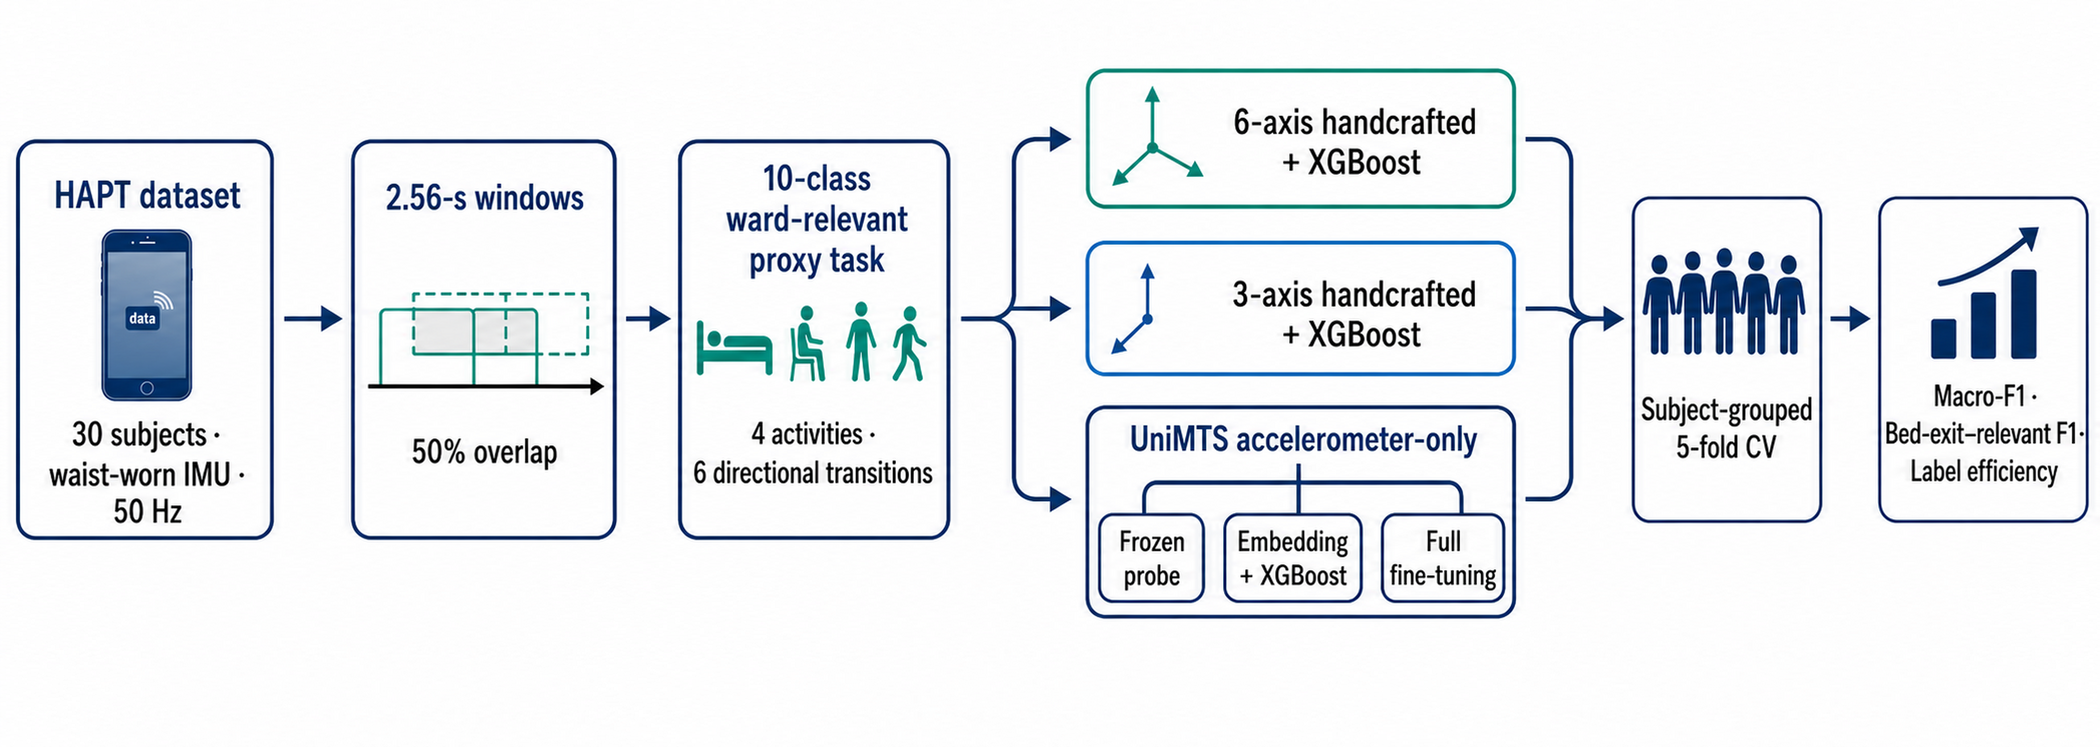

Figure / 그림 2: fig1_headline_decomposition.png 


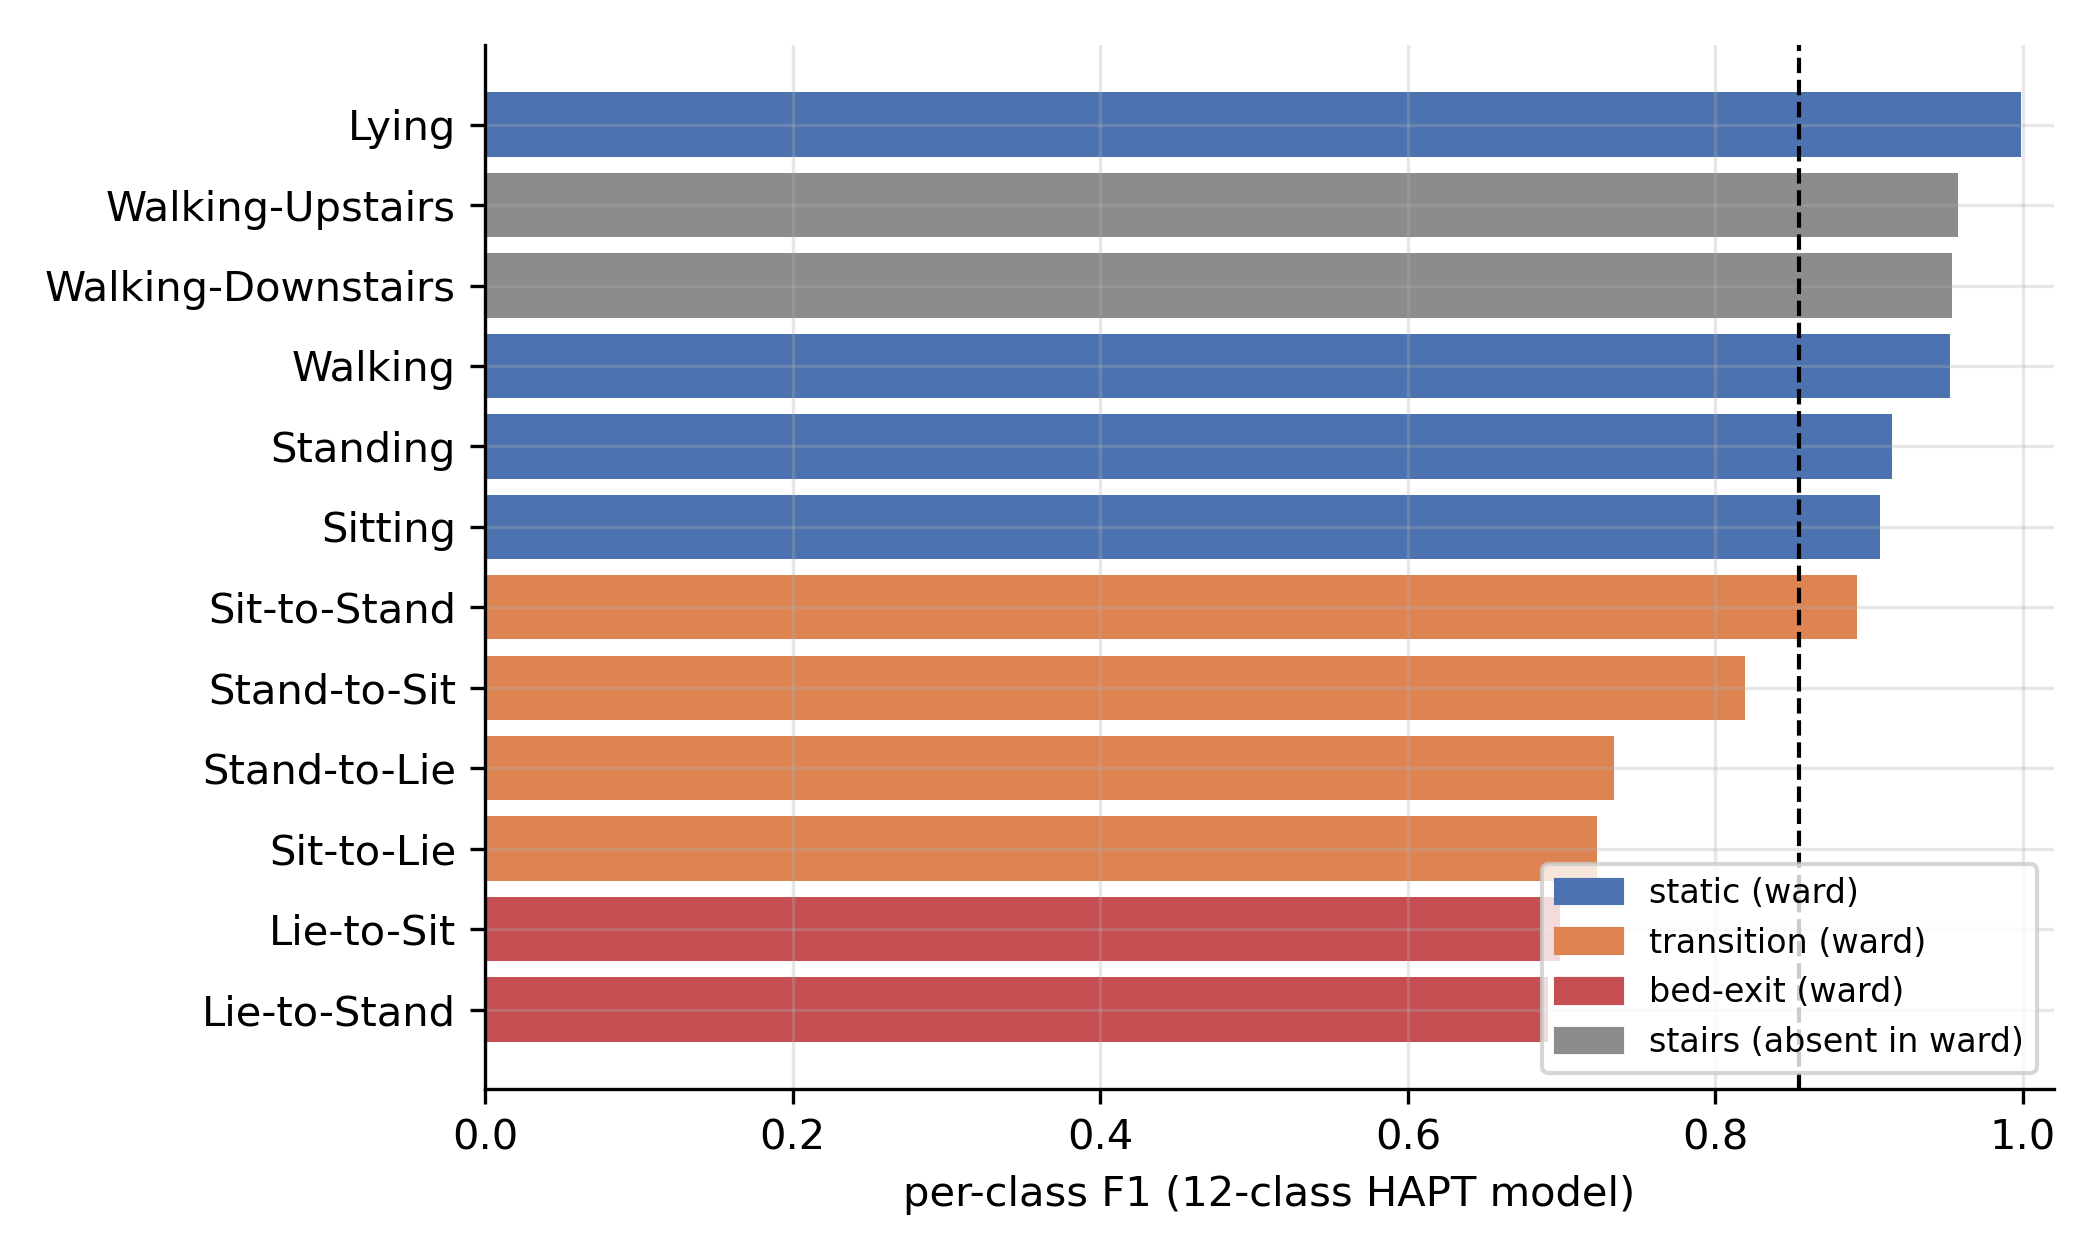

Figure / 그림 3: fig_confusion.png 


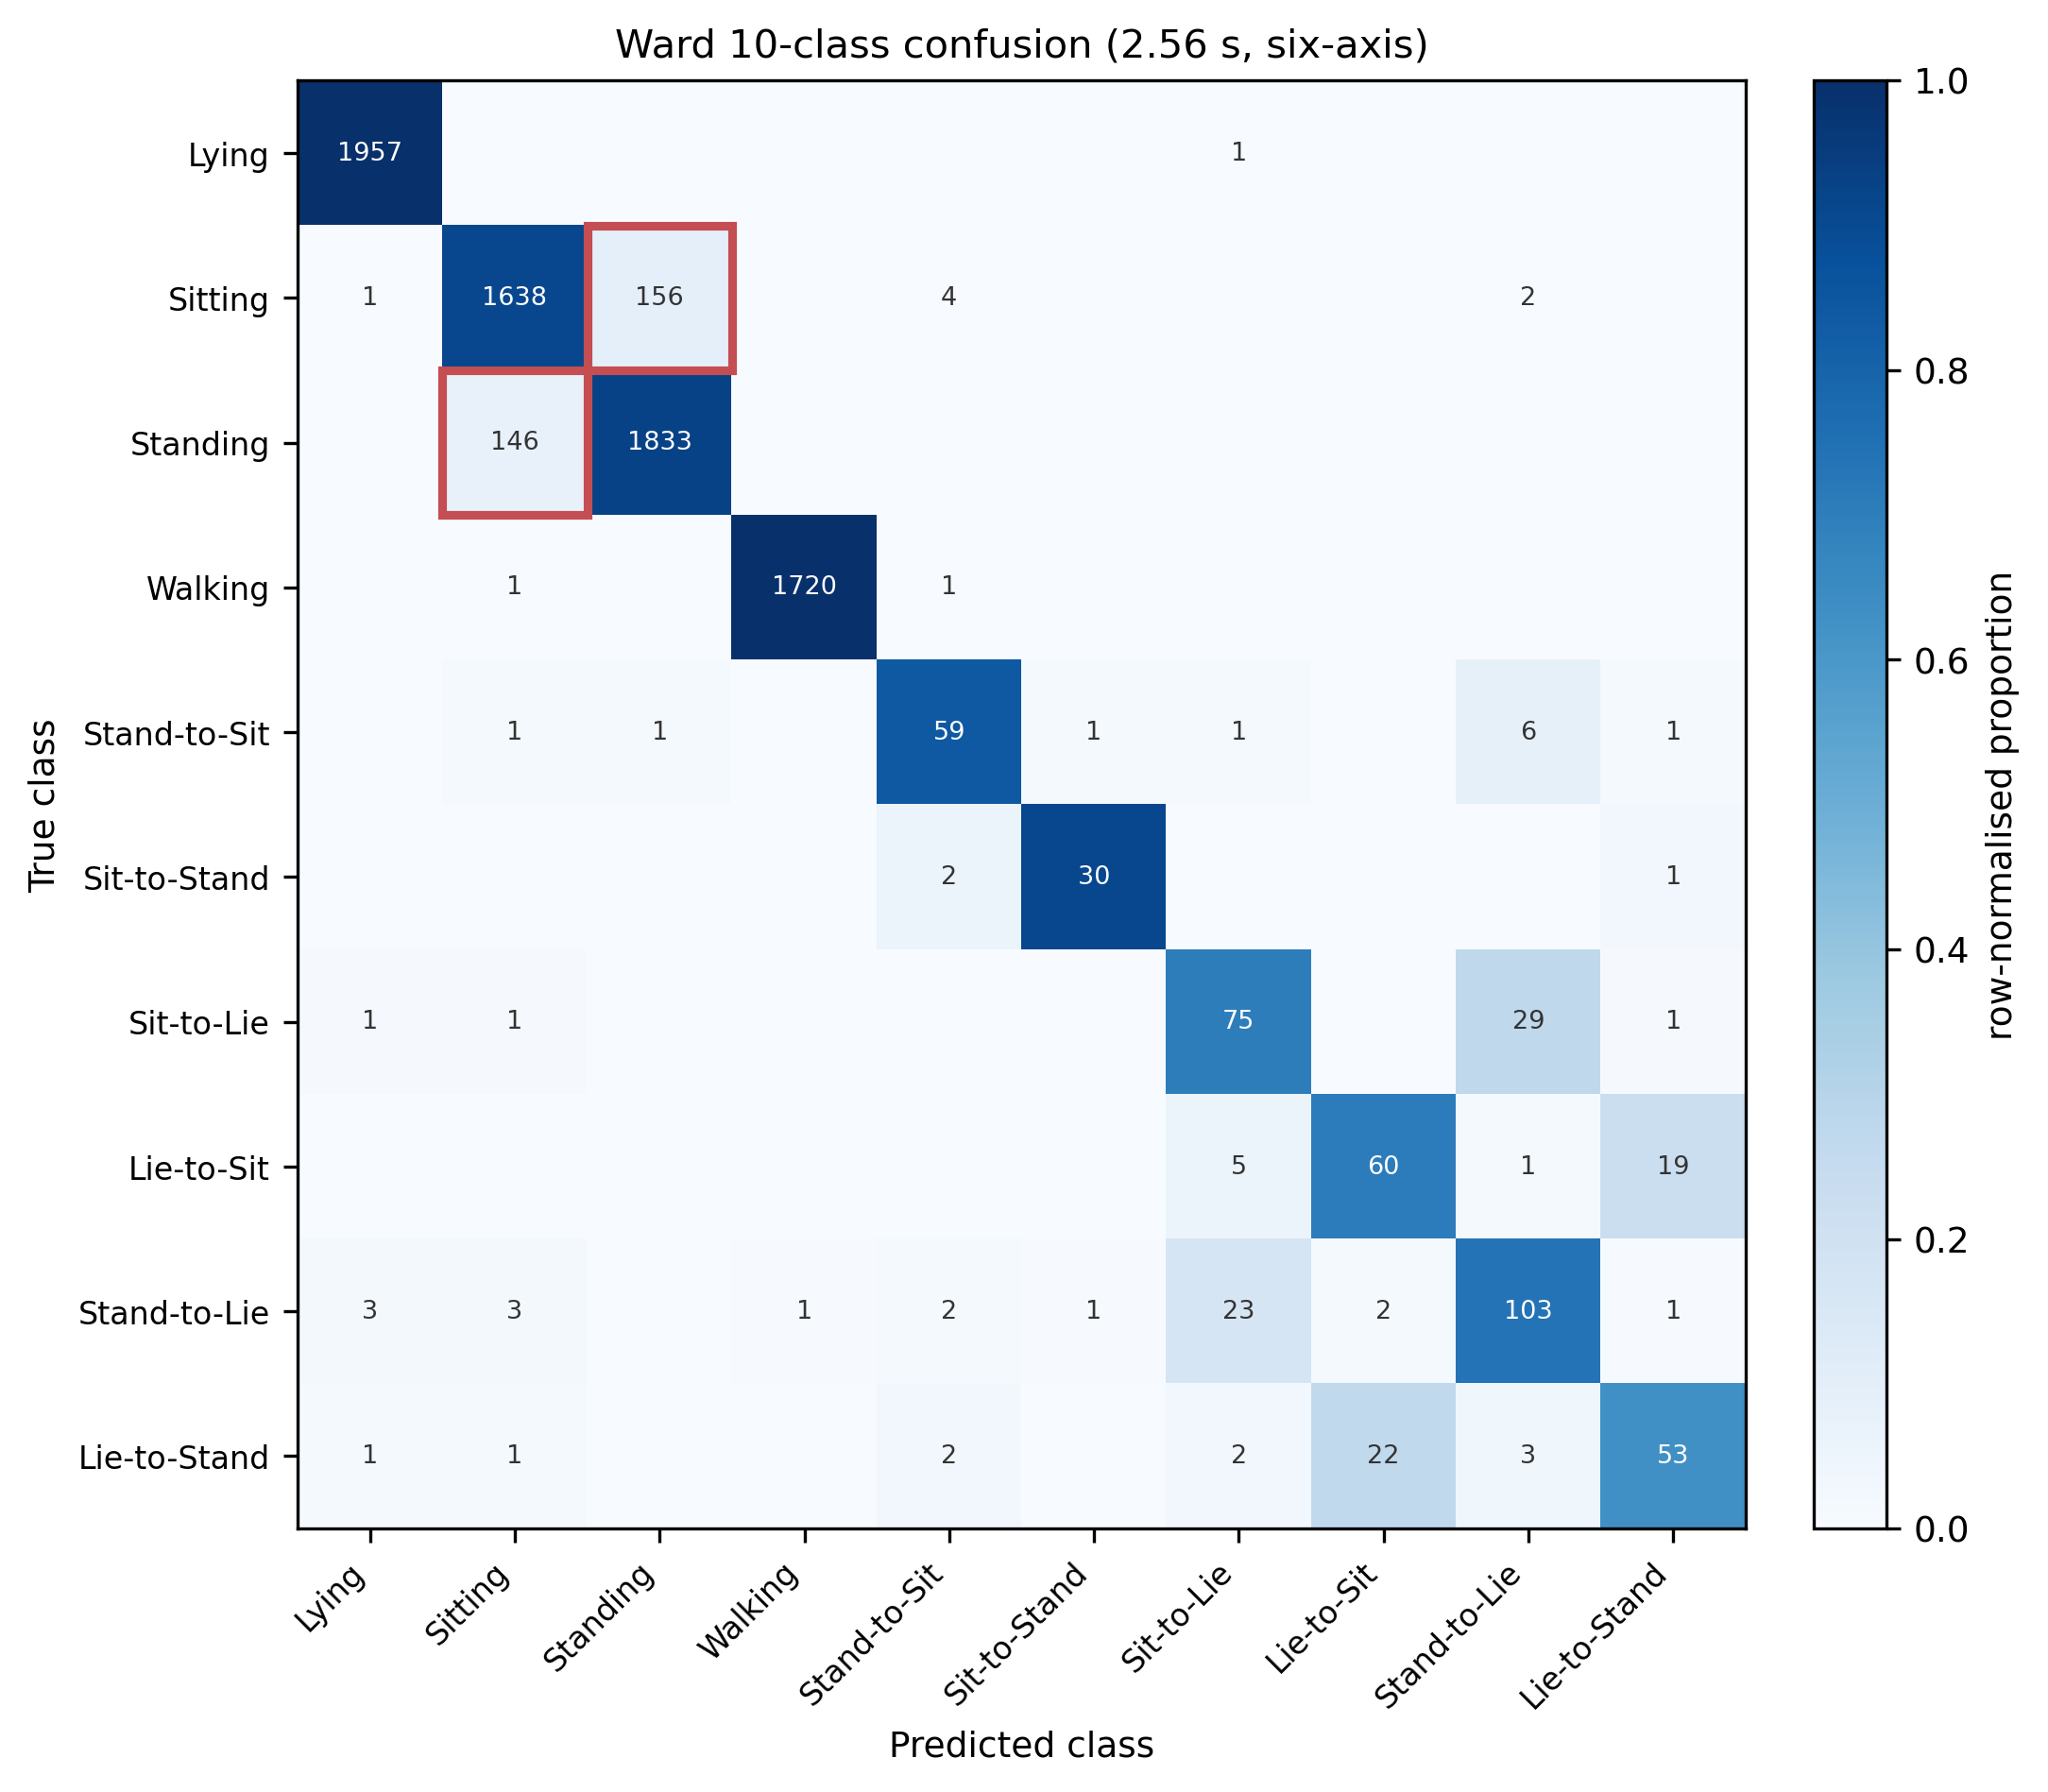

Figure / 그림 4: fig2_gyro_ablation.png 


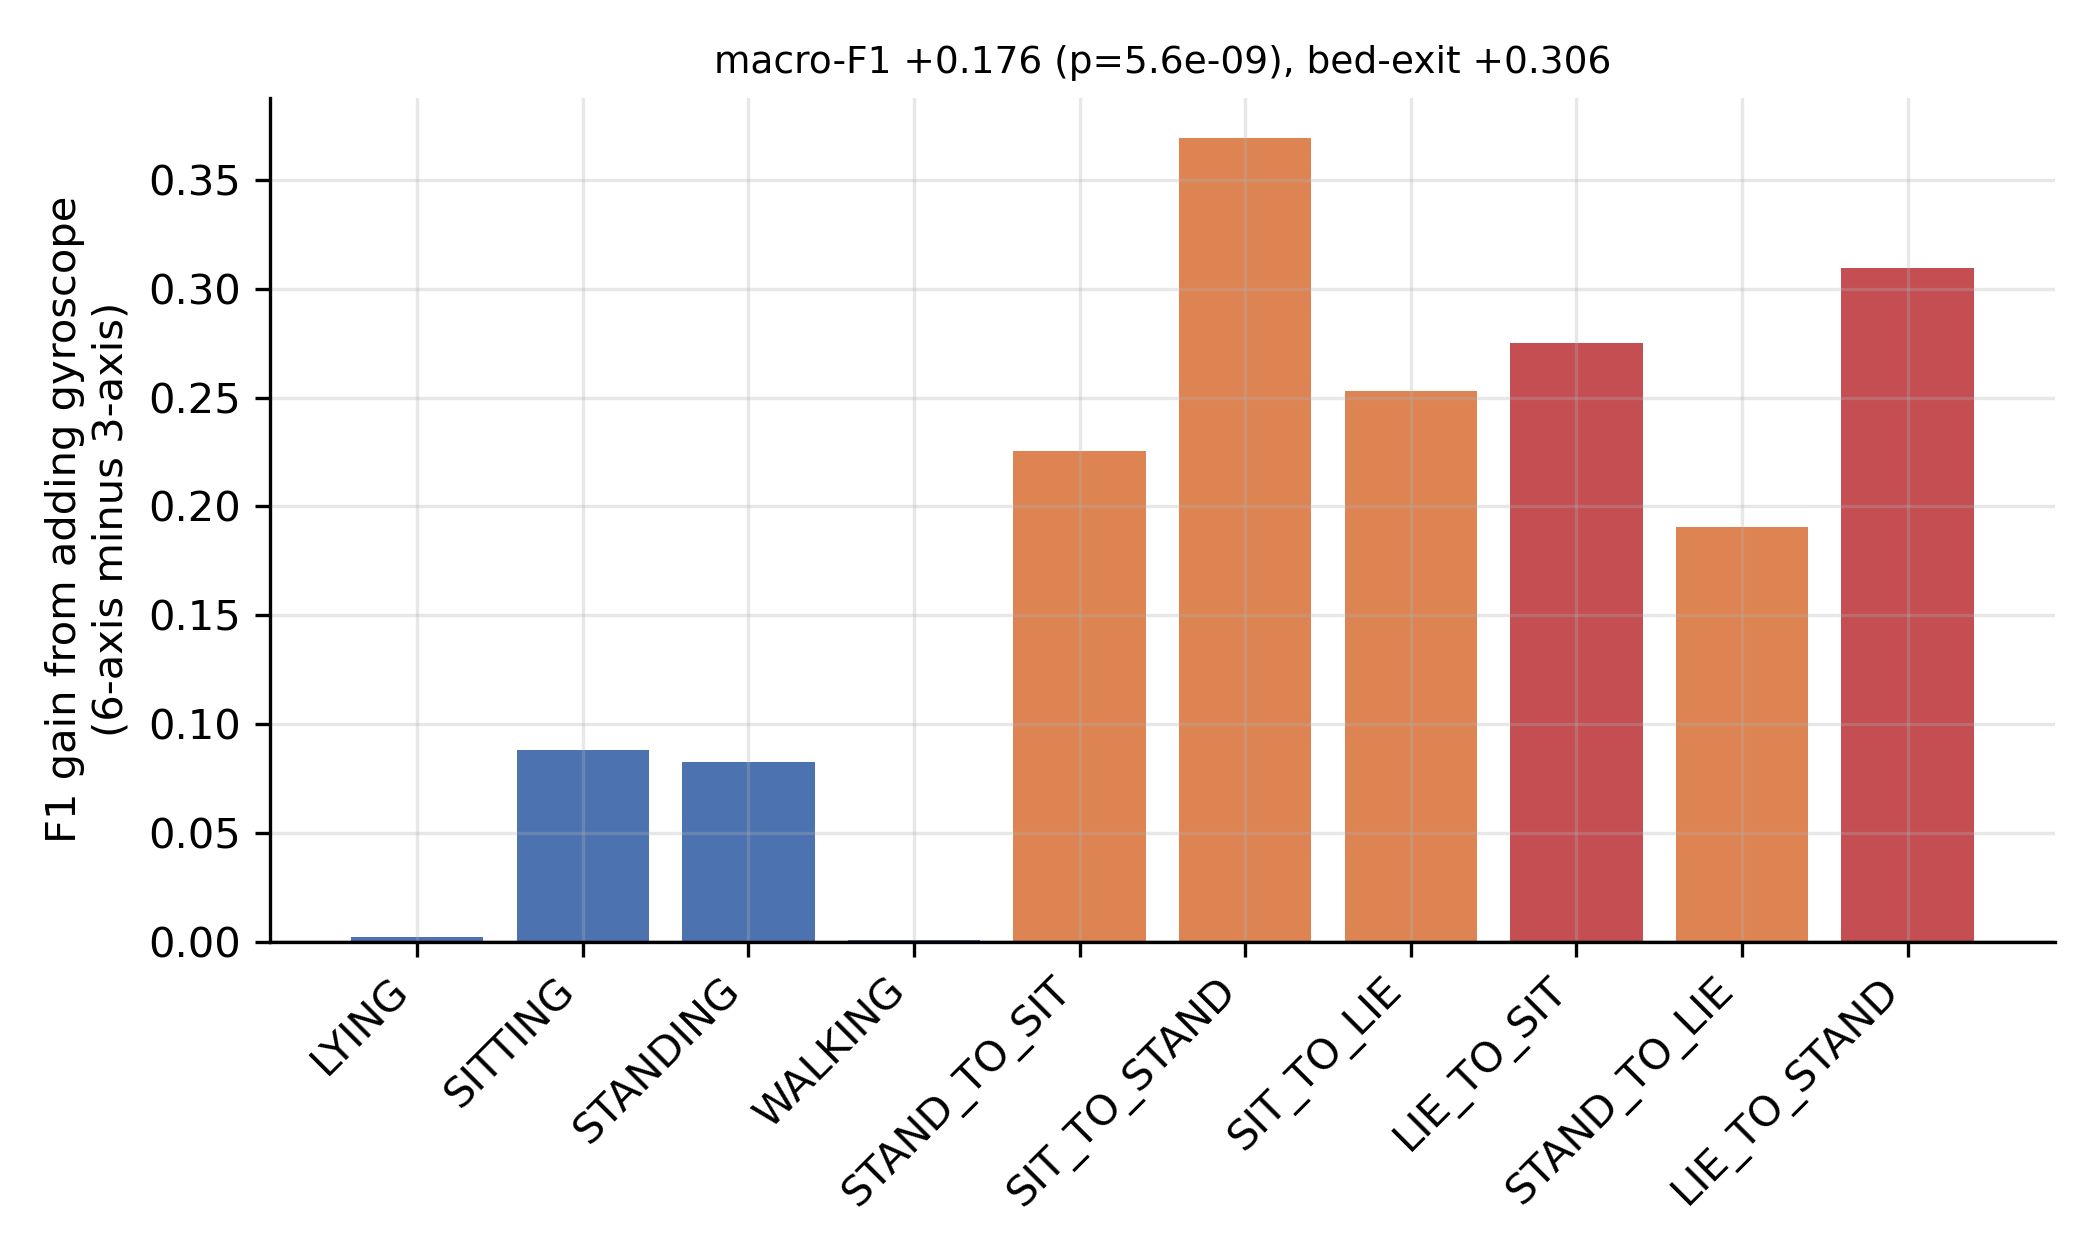

Figure / 그림 5: fig_gyro_paired.png 


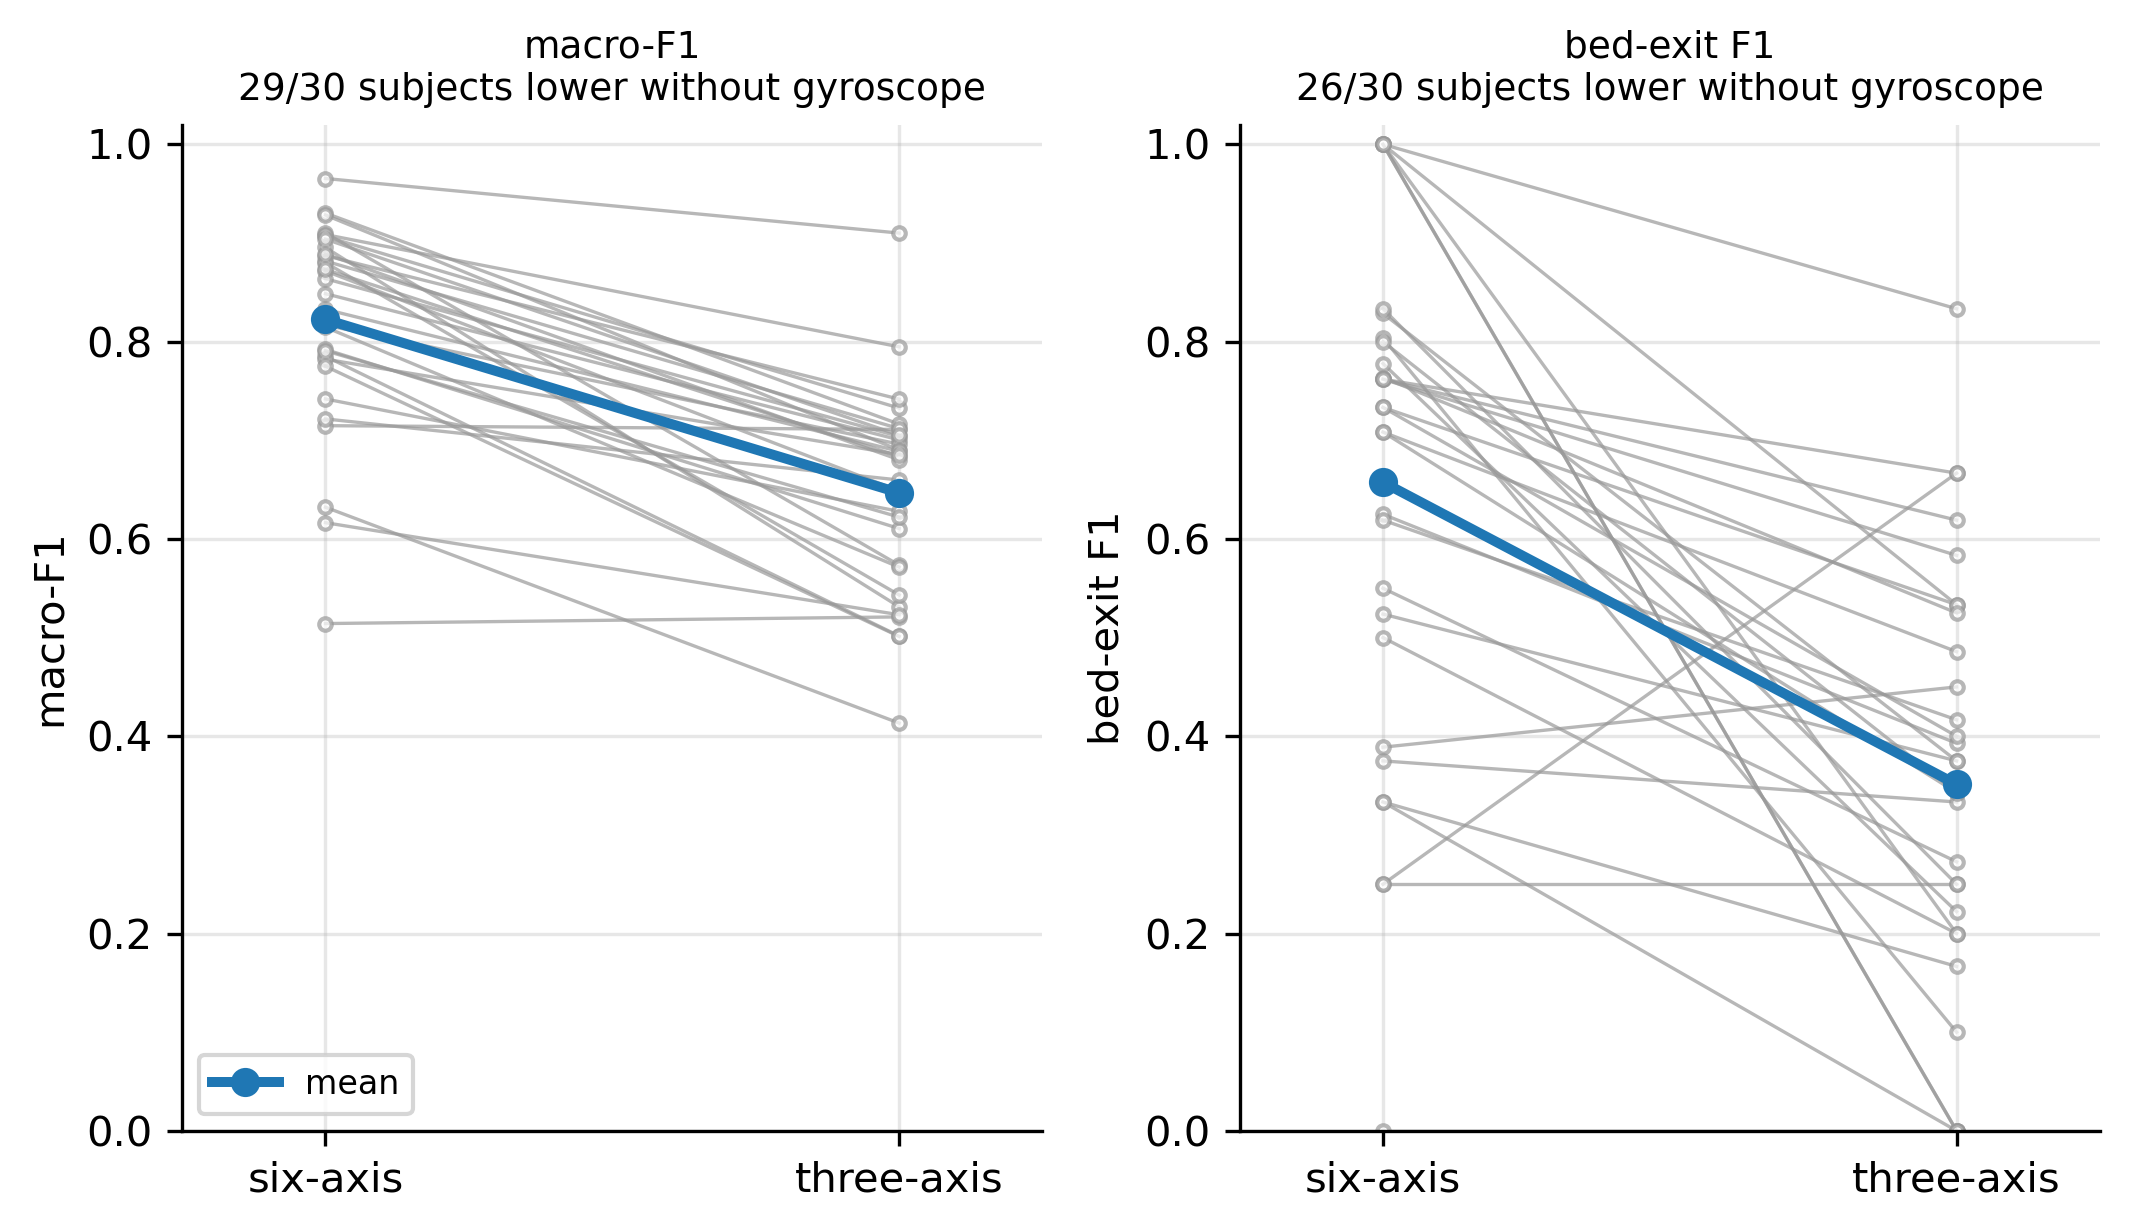

Figure / 그림 6: fig_window_sweep.png 


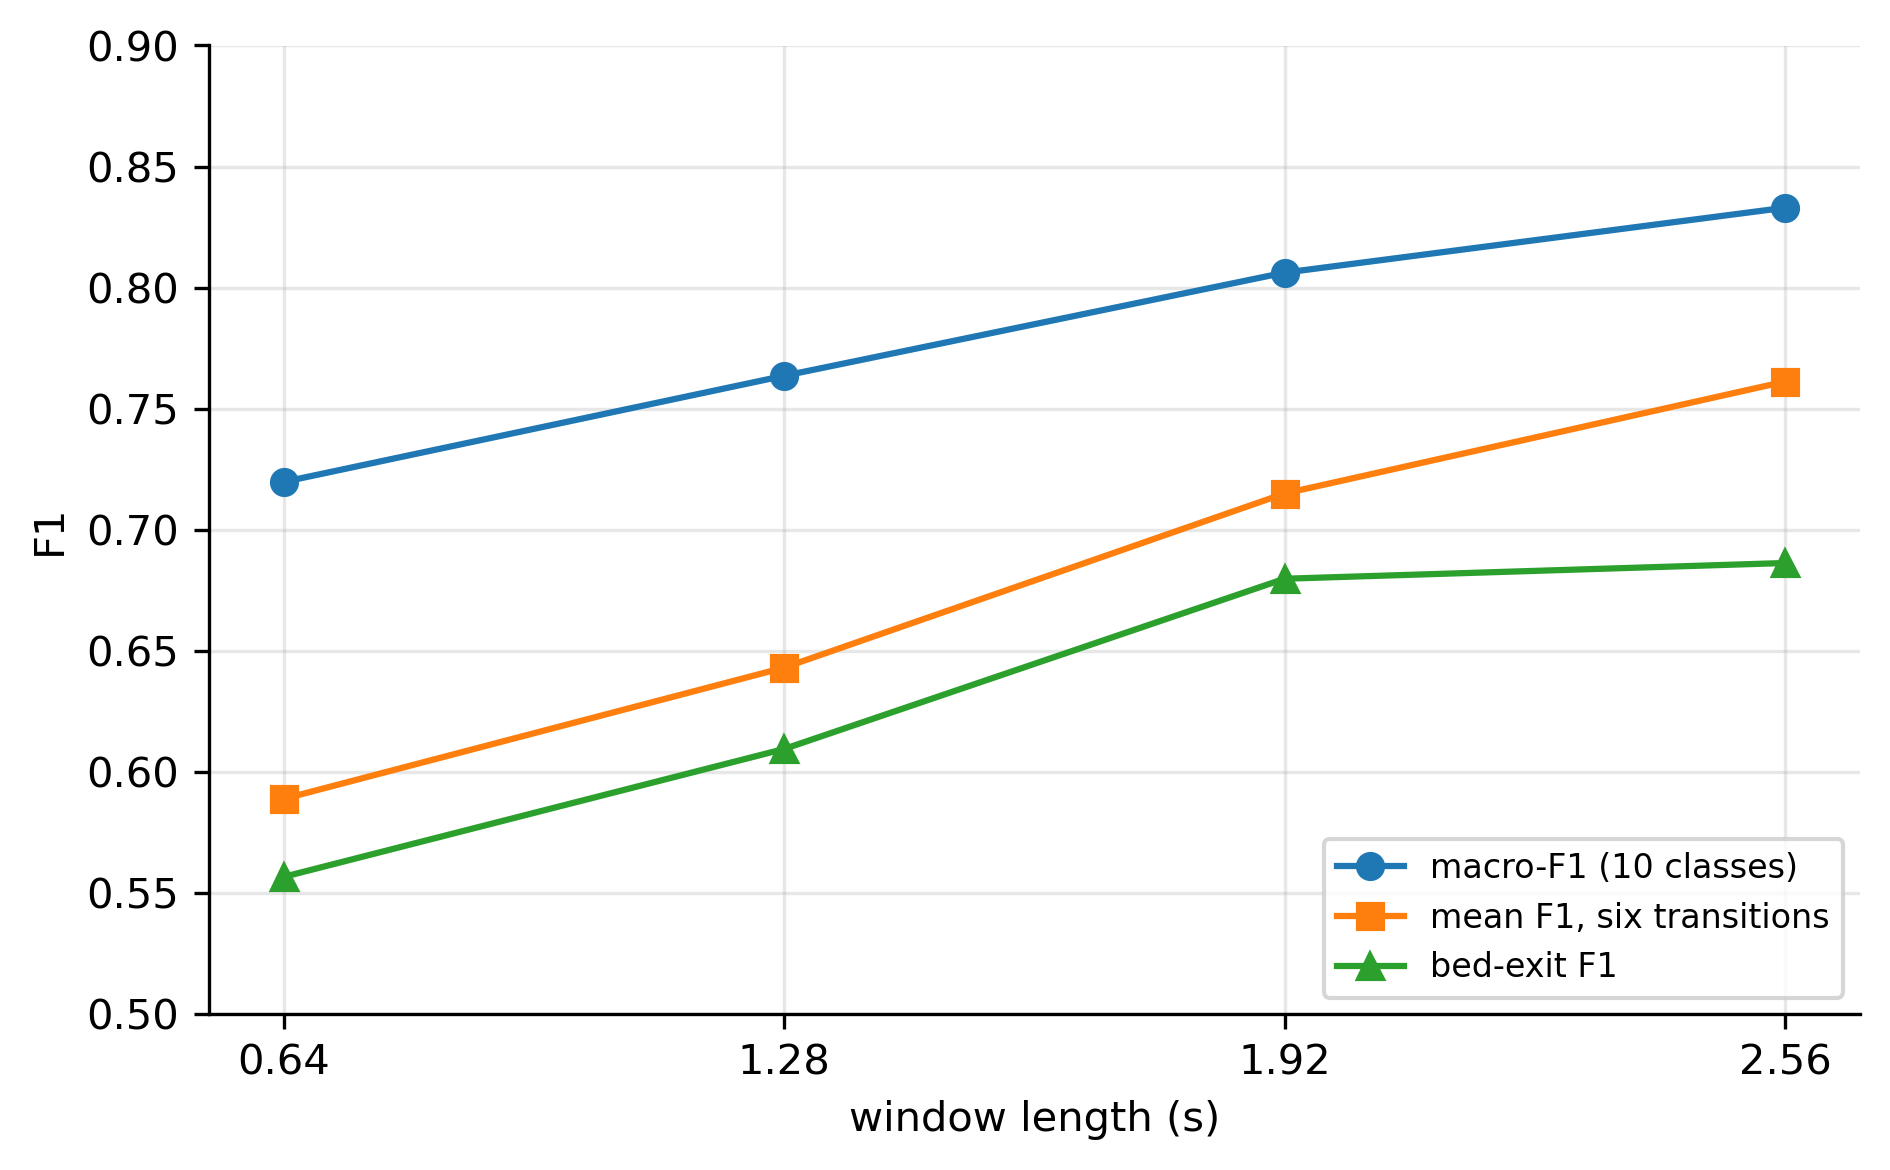

Figure / 그림 7: fig3_label_efficiency.png 


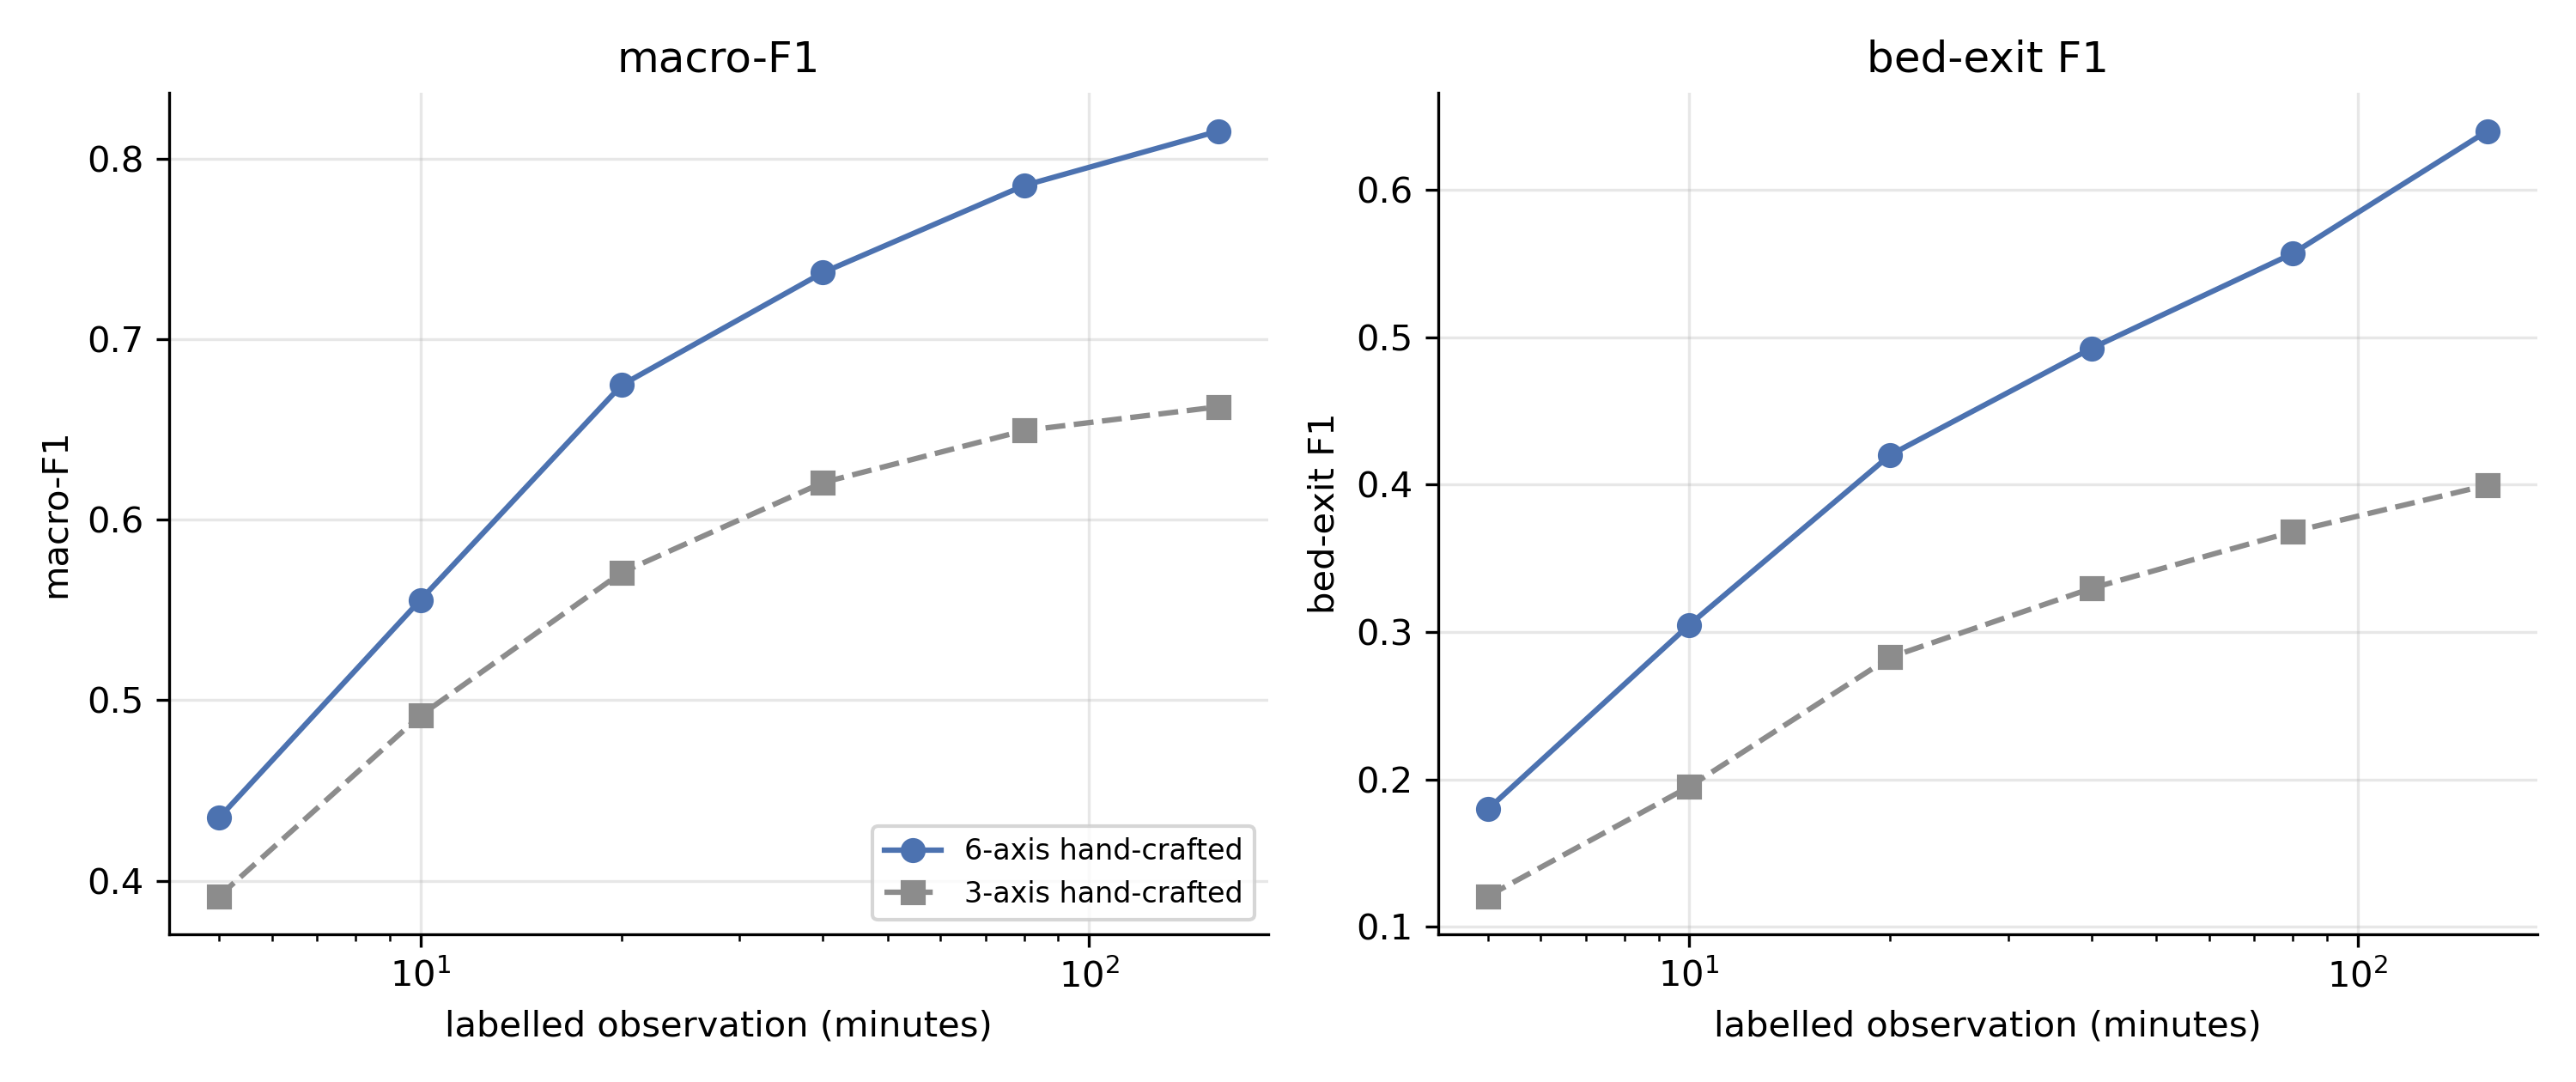

Figure / 그림 8: fig4_representation.png 


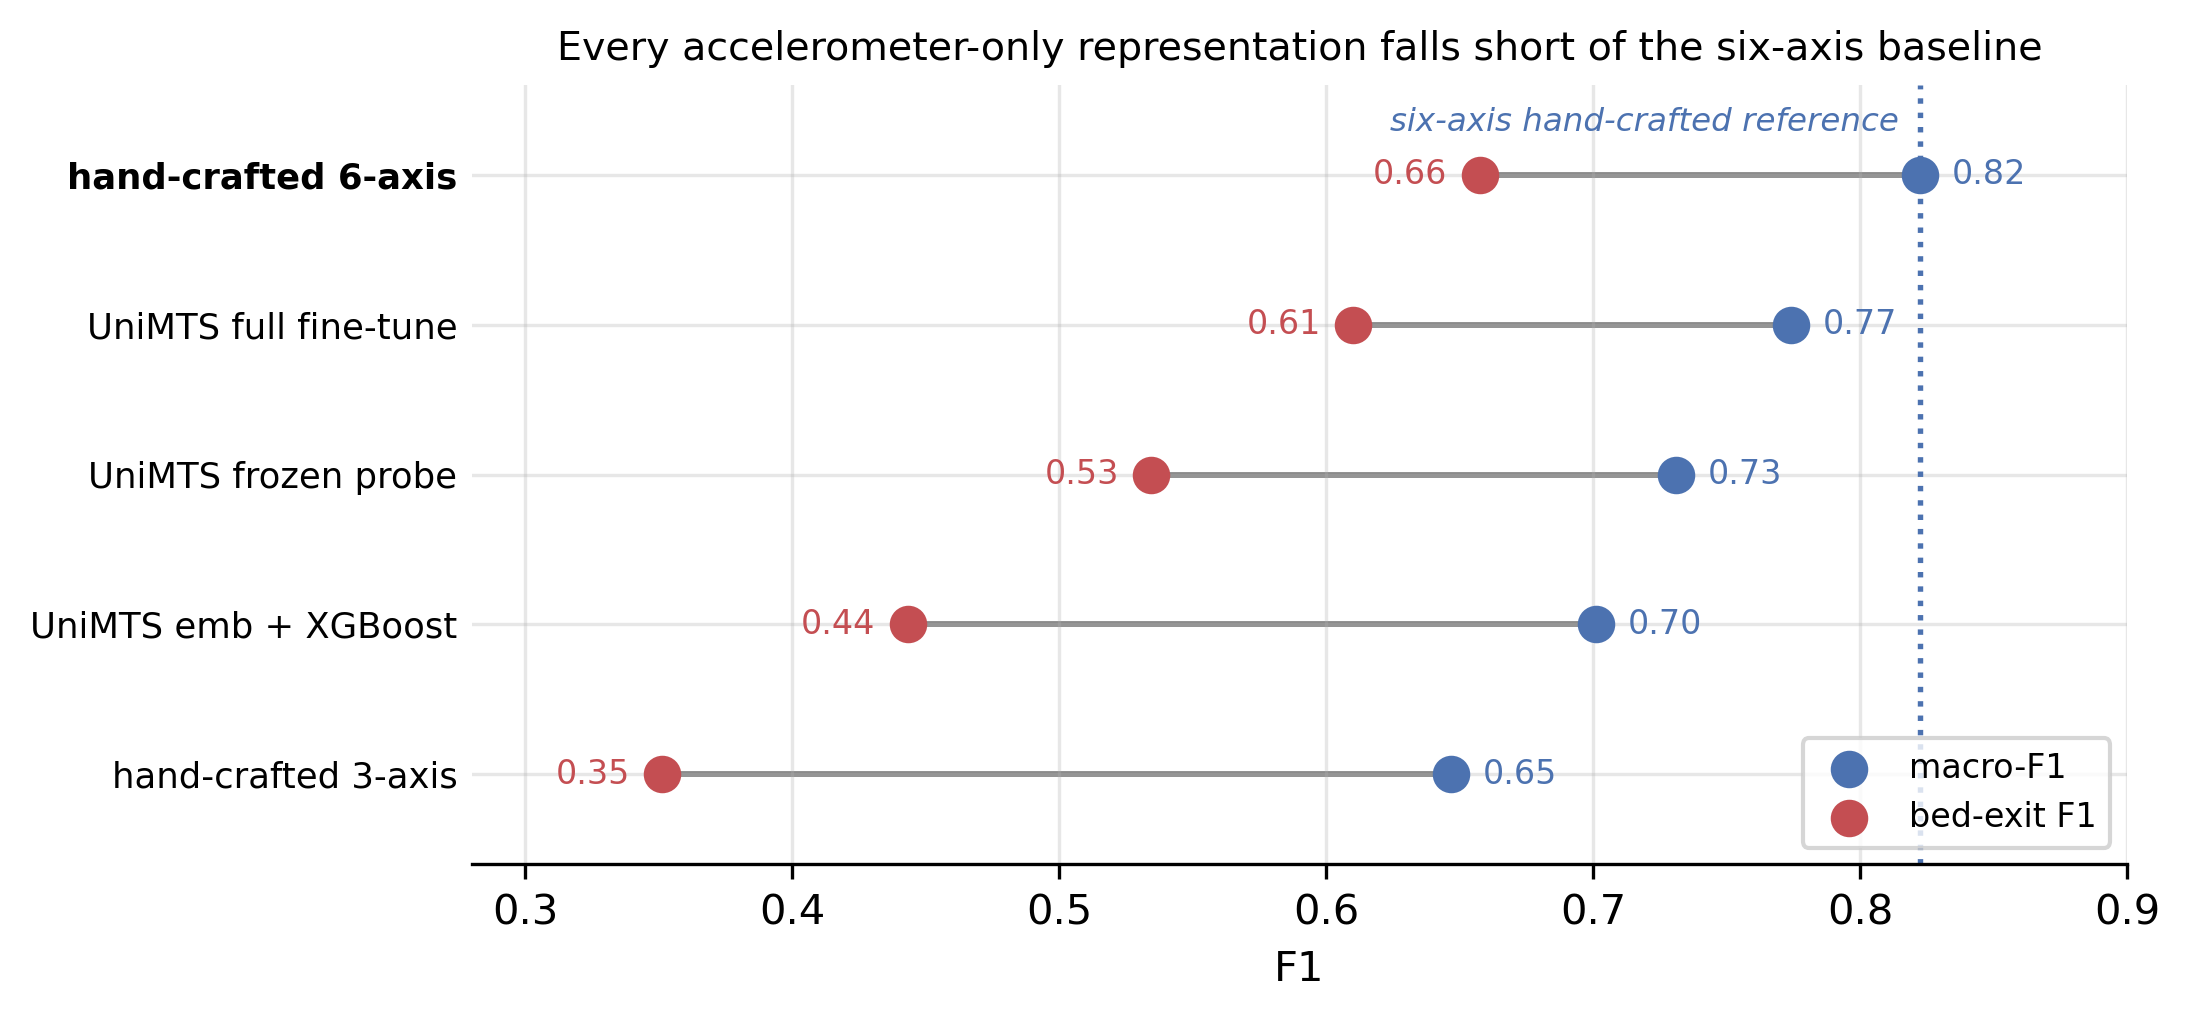

Supplementary Figure S1 / 보충 그림 S1: figS1_representation_scatter.png 


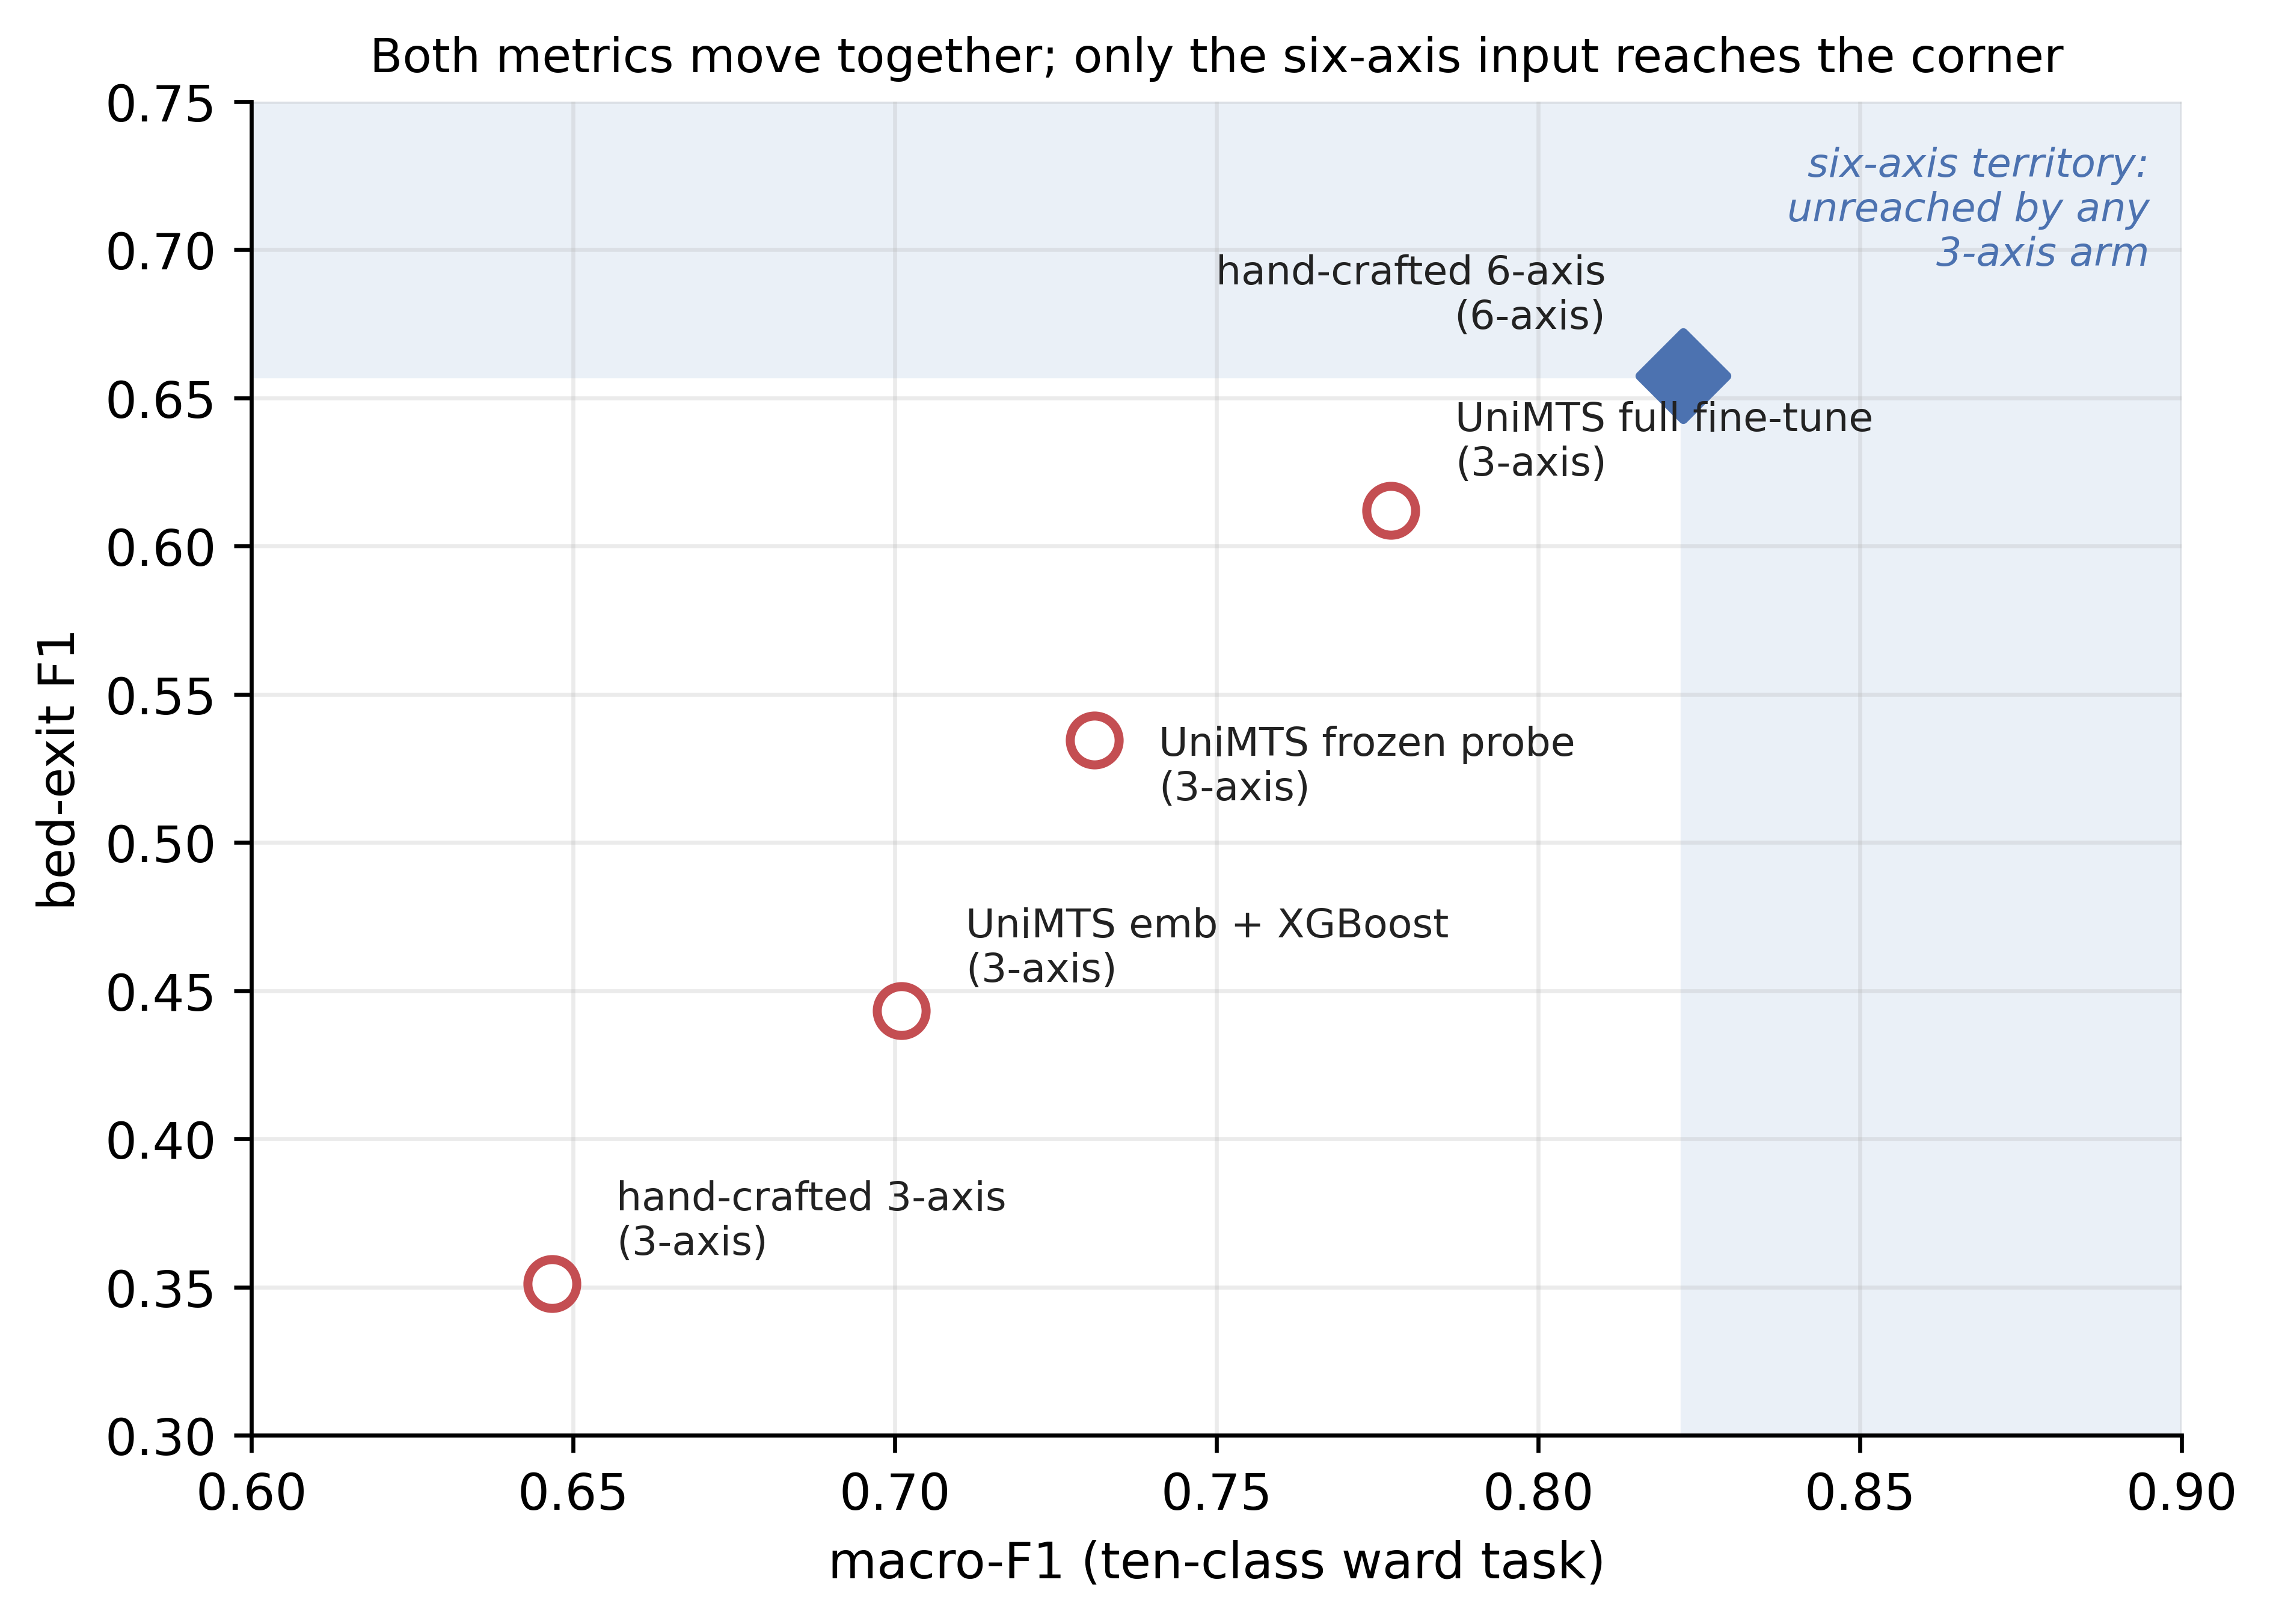

In [3]:
from IPython.display import Image, display
FIGDIR = REPO/'figures'
final_figs = ['fig_pipeline.png','fig1_headline_decomposition.png','fig_confusion.png',
           'fig2_gyro_ablation.png','fig_gyro_paired.png','fig_window_sweep.png',
           'fig3_label_efficiency.png','fig4_representation.png']
for i,f in enumerate(final_figs,1):
    p = FIGDIR/f
    print(f'Figure / 그림 {i}: {f}', '' if p.exists() else '  (not generated yet / 아직 생성 안 됨)')
    if p.exists(): display(Image(filename=str(p), width=560))

pS1 = FIGDIR/'figS1_representation_scatter.png'
print('Supplementary Figure S1 / 보충 그림 S1: figS1_representation_scatter.png',
      '' if pS1.exists() else '  (not generated yet / 아직 생성 안 됨)')
if pS1.exists(): display(Image(filename=str(pS1), width=560))

## Reproduction check — produced numbers vs values printed in the paper
*재현 검증 — 산출 수치 대 논문 기재 값*

**EN.** The cell below reads the freshly produced result files and compares them with the values printed in the paper. Deterministic arms are checked to 4 decimals; the fine-tuned arm is stochastic (see ⑨) and is checked as a 3-seed mean within a tolerance band. If a deterministic row shows `X`, confirm which run is the reported one before editing the manuscript (`results/*_log.txt` is the evidence).

**KR.** 아래 셀은 방금 만들어진 결과 파일을 읽어 논문에 실린 값과 대조합니다. 결정적 arm은 네 자리까지, 미세조정 arm은 확률적이므로(⑨ 참고) 3-시드 평균을 허용범위 안에서 확인합니다. 결정적 행에 `X`가 뜨면 원고를 고치기 전에 어느 실행이 보고본인지부터 확인하세요(`results/*_log.txt`가 근거).

In [3]:
import json

RES = REPO/'results'

# Deterministic arms — values printed in the paper (macro-F1, bed-exit F1); reproduce to 4 decimals on CPU.
# 결정적 arm — 논문 기재 값(macro-F1, 침대이탈 F1); CPU에서 네 자리까지 재현.
REPORTED_DET = {
    'hand6+xgb':      (0.8225, 0.6575),
    'hand3+xgb':      (0.6467, 0.3512),
    'unimts3+xgb':    (0.7010, 0.4432),
    'unimts3+logreg': (0.7310, 0.5345),
}

rows = []
fm = RES/'fm_compare_w128.json'
if not fm.exists():
    fm = RES/'fm_compare_handonly_w128.json'
if fm.exists():
    j = json.loads(fm.read_text())
    for k, v in j.items():
        if isinstance(v, dict) and 'macro_f1_subject_mean' in v and k in REPORTED_DET:
            rows.append((k, v['macro_f1_subject_mean'], v['bed_exit_f1_subject_mean']))

print('Deterministic arms — produced vs reported / 결정적 arm — 산출 대 보고')
print(f'{"arm":18} {"produced m/bed":>16}  {"reported m/bed":>16}  ok')
bad = 0
for k, m, b in rows:
    rm, rb = REPORTED_DET[k]
    ok = abs(m - rm) < 5e-4 and abs(b - rb) < 5e-4
    bad += (not ok)
    print(f'{k:18} {m:.4f}/{b:.4f}      {rm:.4f}/{rb:.4f}      {"O" if ok else "X"}')

missing = [k for k in REPORTED_DET if k not in {r[0] for r in rows}]
if missing:
    print('not produced yet (⑤/⑧ not run) / 아직 산출 안 됨:', ', '.join(missing))

# Full fine-tuning (⑨) — the paper reports the 3-SEED MEAN, not a single run. CUDA fine-tuning
# is not bit-reproducible, so the mean varies between runs; we check it lies within a generous
# band of the paper's 0.774±0.019 / 0.610±0.021.
# 완전 미세조정(⑨) — 논문은 단일 실행이 아니라 3-시드 평균을 보고. CUDA 미세조정은
# bit-재현이 안 되어 평균도 실행마다 달라지므로, 0.774±0.019 / 0.610±0.021 을 넉넉한 허용범위로 확인.
print()
print('Full fine-tuning ⑨ — 3-seed mean / 완전 미세조정 ⑨ — 3-시드 평균')
PAPER_FT = (0.774, 0.610)   # macro, bed-exit (3-seed mean)
ms = RES/'finetune_full_w128_multiseed.json'
if ms.exists():
    jm = json.loads(ms.read_text())
    mm, ms_sd = jm['macro_f1_seed_mean'], jm['macro_f1_seed_sd']
    bm, bs_sd = jm['bed_exit_f1_seed_mean'], jm['bed_exit_f1_seed_sd']
    n = jm.get('n_seeds')
    ok_ft = abs(mm - PAPER_FT[0]) < 0.03 and abs(bm - PAPER_FT[1]) < 0.04
    print(f'  produced ({n} seeds): macro {mm:.4f}±{ms_sd:.4f}  bed-exit {bm:.4f}±{bs_sd:.4f}')
    print(f'  paper            : macro {PAPER_FT[0]:.3f}±0.019  bed-exit {PAPER_FT[1]:.3f}±0.021')
    print(f'  within band      : {"O" if ok_ft else "X (stochastic — check per-seed spread)"}')
    bad += (not ok_ft)
else:
    print('  no multiseed file yet — run ⑨ (it then calls aggregate_finetune_seeds.py)')
    print('  (아직 없음 — ⑨를 돌리면 aggregate_finetune_seeds.py 가 생성)')

# Single reference seed (finetune_full_w128.json) — informational. Holds the seed-0 reference run
# (0.7726/0.5550), kept so ⑥ redraws figures identically; NOT the paper's headline ft-full number.
# 단일 기준 시드(finetune_full_w128.json) — 참고용. seed-0 기준 실행(0.7726/0.5550)을 담아
# ⑥이 그림을 동일하게 다시 그리도록 보존한 것이며, 논문 헤드라인 값은 아닙니다.
ref = RES/'finetune_full_w128.json'
if ref.exists():
    jr = json.loads(ref.read_text())
    print()
    print(f'  reference seed-0 file / 기준 seed-0 파일: macro {jr["macro_f1_mean"]:.4f}  bed-exit {jr["bed_exit_f1_mean"]:.4f}'
          f'  (vs 0.7726/0.5550, informational)')

print()
print('mismatches / 불일치:', bad)

print()
print('=== step run status / 단계 실행 상태 ===')
if not FAILED:
    print('all steps finished with exit code 0 / 모든 단계 종료코드 0.')
else:
    print(f'{len(FAILED)} step(s) with non-zero exit — the table may read "O" but those steps did not run:')
    print(f'종료코드가 0이 아닌 단계 {len(FAILED)}건 — 위 표가 "O"여도 그 단계는 실제로 돌지 않았습니다:')
    for cmd, rc in FAILED:
        print(f'  [{rc}] {cmd}')
    print()
    print('On a CPU-only PC, ⑦·⑨ (need torch/UniMTS) and the checkpoint check are expected to fail;')
    print('the ft-full rows then reflect the archived files, not a fresh run.')
    print('CPU 전용 PC에서는 ⑦·⑨와 체크포인트 검증 실패가 정상이며, ft-full 값은 보관본을 읽은 것입니다.')

Deterministic arms — produced vs reported / 결정적 팔 — 산출 대 보고
arm                  produced m/bed    reported m/bed  ok
hand6+xgb          0.8225/0.6575      0.8225/0.6575      O
hand3+xgb          0.6467/0.3512      0.6467/0.3512      O
unimts3+xgb        0.7010/0.4432      0.7010/0.4432      O
unimts3+logreg     0.7310/0.5345      0.7310/0.5345      O

Full fine-tuning ⑨ — 3-seed mean / 완전 미세조정 ⑨ — 3-시드 평균
  produced (3 seeds): macro 0.7739±0.0192  bed-exit 0.6100±0.0212
  paper            : macro 0.774±0.019  bed-exit 0.610±0.021
  within band      : O

  reference seed-0 file / 기준 seed-0 파일: macro 0.7726  bed-exit 0.5550  (vs 0.7726/0.5550, informational)

mismatches / 불일치: 0

=== step run status / 단계 실행 상태 ===
all steps finished with exit code 0 / 모든 단계 종료코드 0.


## ⑩ Bed-exit sensitivity (recall) — paper §3.1
*⑩ 침대이탈 민감도(재현율)*

**EN.** Reproduces the bed-exit **recall (sensitivity)** reported in the paper, read from step ③ output (`transitions_results.json`): the fraction of true bed-exit transitions the six-axis model detects.

**KR.** 논문에 보고한 침대이탈 **재현율(민감도)** 을 ③단계 산출물(`transitions_results.json`)에서 재현한다 — 6축 모델이 실제 침대 이탈 전환을 얼마나 포착하는가.

In [2]:
# 10 Bed-exit recall (sensitivity) reported in the paper (from step 3 -> transitions_results.json).
import json
_RES = REPO / 'results'
_tr = json.loads((_RES / 'transitions_results.json').read_text())
_w = next(e for e in (_tr if isinstance(_tr, list) else [_tr]) if e.get('win') == 128)
print('Bed-exit recall / precision - six-axis model (paper 3.1):')
for r in _w['bed_exit']:
    print(f"  {r['class']:<13s} recall {r['recall']:.2f}   precision {r['precision']:.2f}")

Bed-exit recall / precision - six-axis model (paper 3.1):
  LIE_TO_SIT    recall 0.71   precision 0.71
  LIE_TO_STAND  recall 0.63   precision 0.70
